# Mass Roads Label Graph Overlay

This notebook loops through all label masks in:

`/home/ri/Desktop/Projects/Datasets/Mass_Roads/dataset/train/label/`

For each label:
1. Loads and binarizes the label mask
2. Extracts a graph with `mask2graph.extract_graph`
3. Plots the label and graph overlay together

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

# Ensure local package import works when running notebook from repo root
repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mask2graph import ExtractConfig, extract_graph

In [2]:
label_dir = Path('/home/ri/Desktop/Projects/Datasets/Mass_Roads/dataset/train/label')
label_paths = sorted(label_dir.glob('*.tif'))

print(f'Label directory: {label_dir}')
print(f'Total label files: {len(label_paths)}')
print('First 5 files:', [p.name for p in label_paths[:5]])

Label directory: /home/ri/Desktop/Projects/Datasets/Mass_Roads/dataset/train/label
Total label files: 1108
First 5 files: ['10078660_15.tif', '10078675_15.tif', '10078690_15.tif', '10078705_15.tif', '10078720_15.tif']


In [3]:
# Optional: adjust config if needed
config = ExtractConfig()

# Conservative mask cleanup (pixel units because spacing isn't passed in this notebook)
config.cleanup.min_object_size = 9.0
config.cleanup.max_hole_size = 36.0
config.cleanup.max_hole_radius = 2.0

# Junction stabilization and iterative graph normalization (conservative defaults)

# stronger junction stabilization + graph cleanup
config.normalize.junction_dilation_iters = 5      # was 1
config.normalize.prune_spurs_below = 10.0         # was 8
config.normalize.min_component_length = 30.0      # was 25
config.normalize.min_cycle_length = 18.0          # was 12
config.normalize.max_cycle_area = 24.0            # was 16
config.normalize.cycle_length_to_radius_ratio = 5.0  # was 8 (stricter)
config.normalize.contract_short_edges_below = 8.0 # was 2
config.normalize.normalization_max_iter = 20      # was 8

# If you want to test quickly first, set a number (e.g. 20). Keep as None for all labels.
# max_files = None
max_files = 20

In [4]:
def load_binary_label(path: Path) -> np.ndarray:
    arr = imread(path)
    if arr.ndim > 2:
        arr = arr[..., 0]
    return (arr != 0)


def plot_graph_overlay(mask: np.ndarray, graph, title: str) -> None:
    fig, ax = plt.subplots(figsize=(16, 16))
    ax.imshow(mask, cmap='gray', interpolation='nearest')

    # Draw edges as cyan polylines (x,y from xyz)
    for edge in graph.edges:
        xy = edge.path_xyz[:, :2]
        ax.plot(xy[:, 0], xy[:, 1], color='cyan', linewidth=1.0, alpha=0.85)

    # Draw nodes as red points
    if graph.nodes:
        node_xy = np.array([[n.xyz[0], n.xyz[1]] for n in graph.nodes], dtype=np.float64)
        ax.scatter(node_xy[:, 0], node_xy[:, 1], s=50, c='red', marker='o', alpha=0.9)

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

Processing 20 label files...


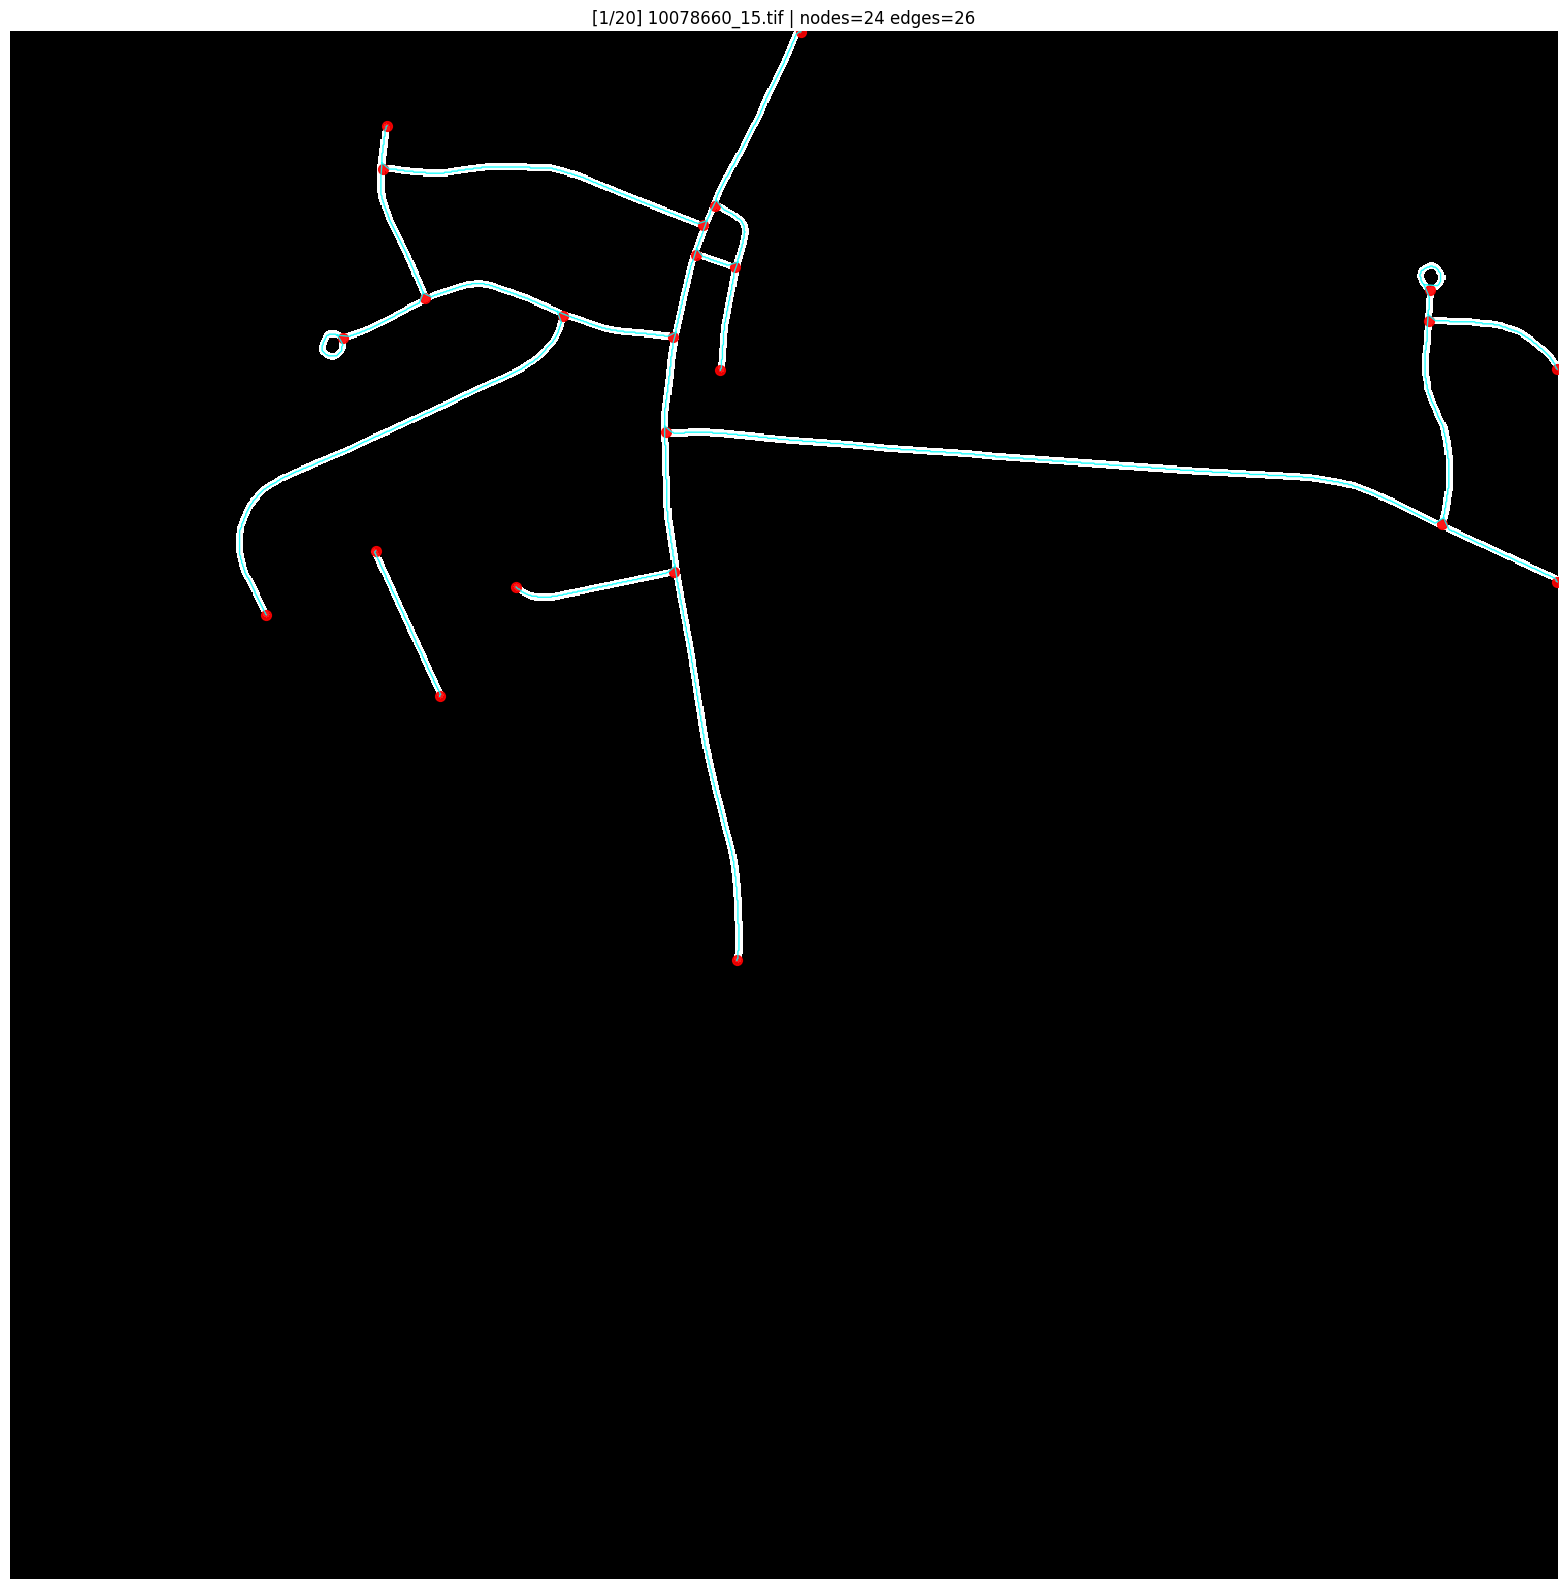

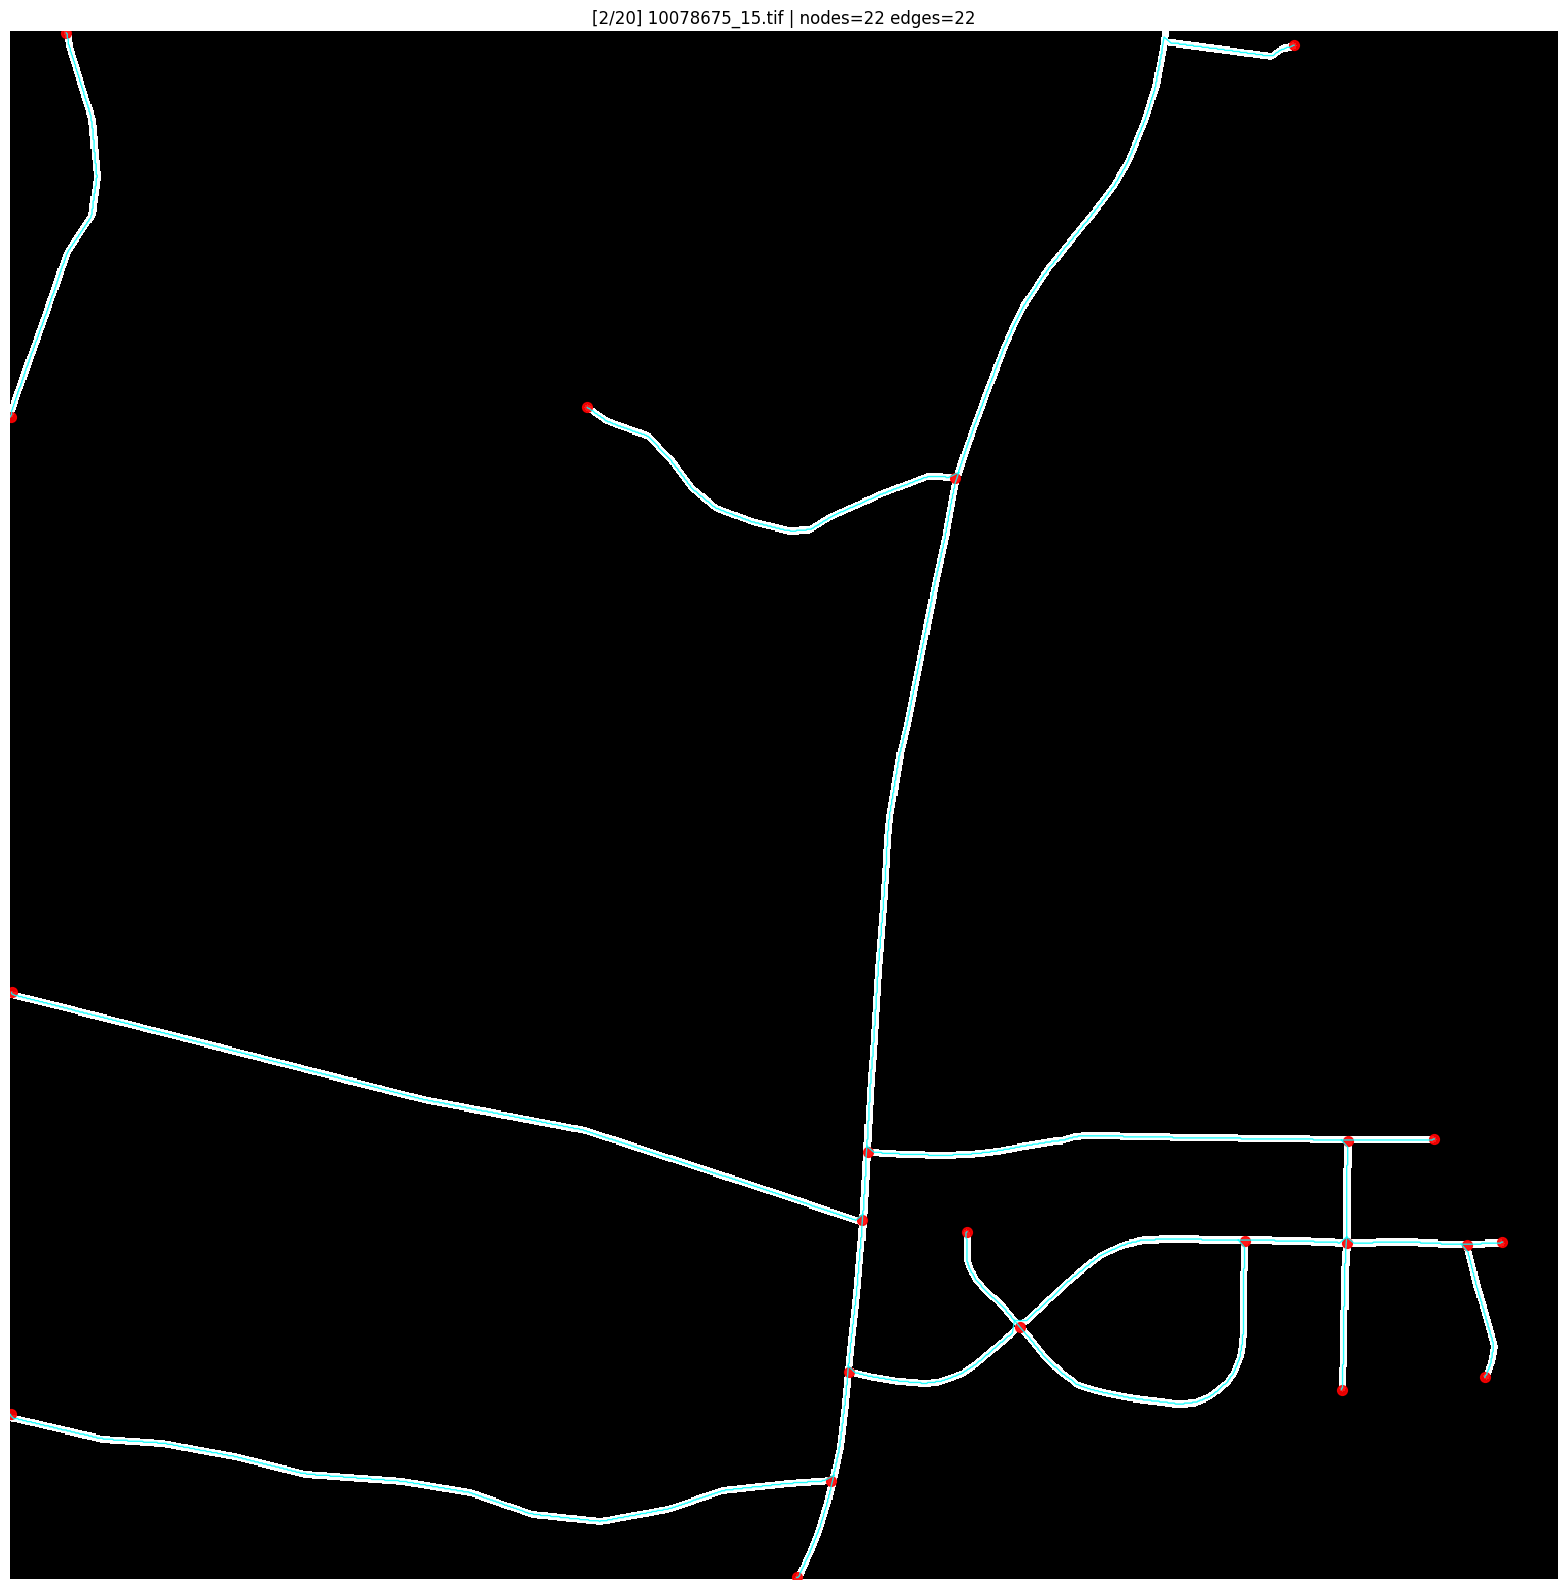

10078690_15.tif: removed=0, filled_holes=1, nodes=35, edges=37


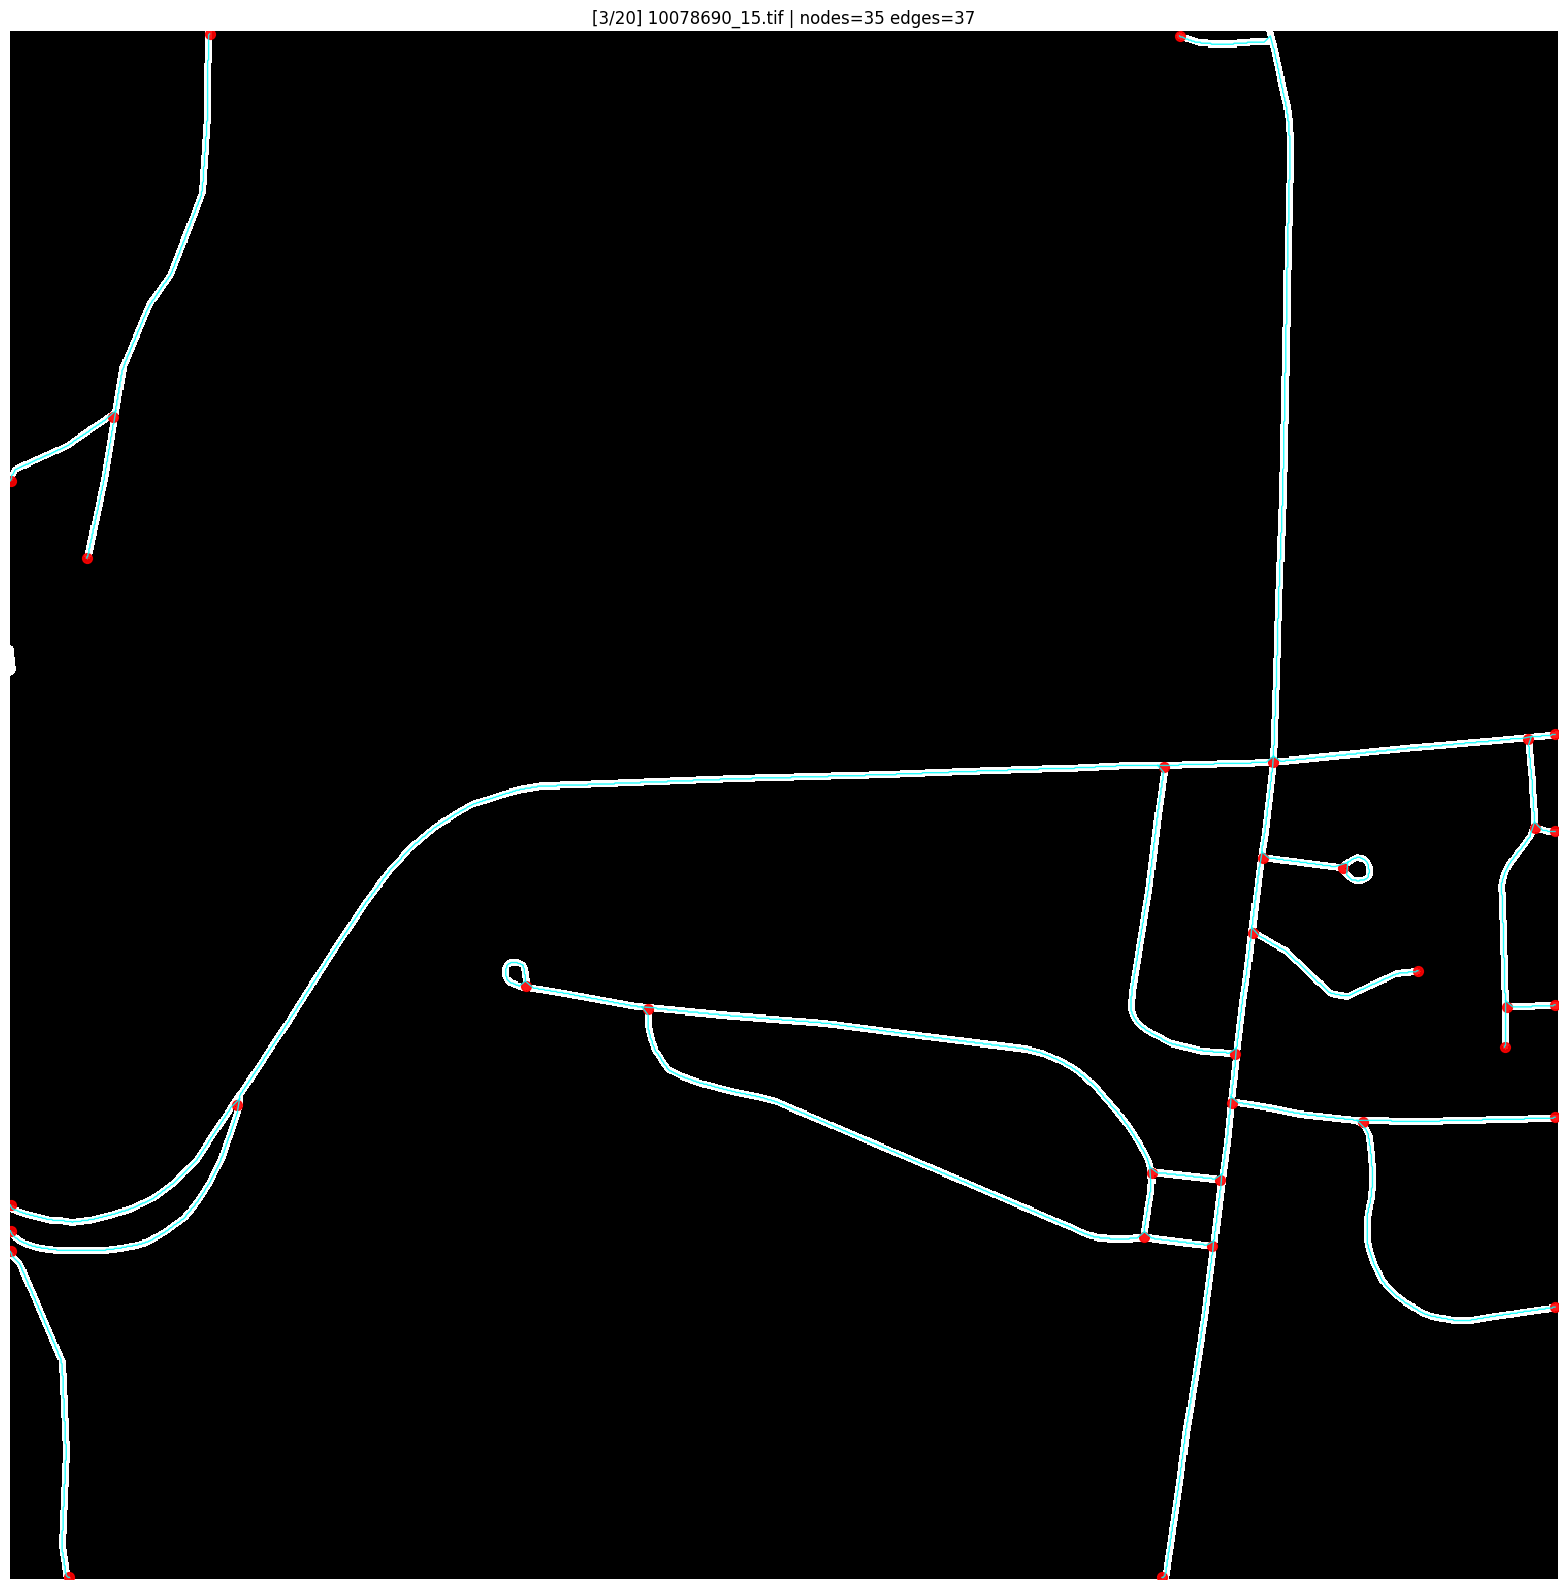

10078705_15.tif: removed=0, filled_holes=4, nodes=20, edges=18


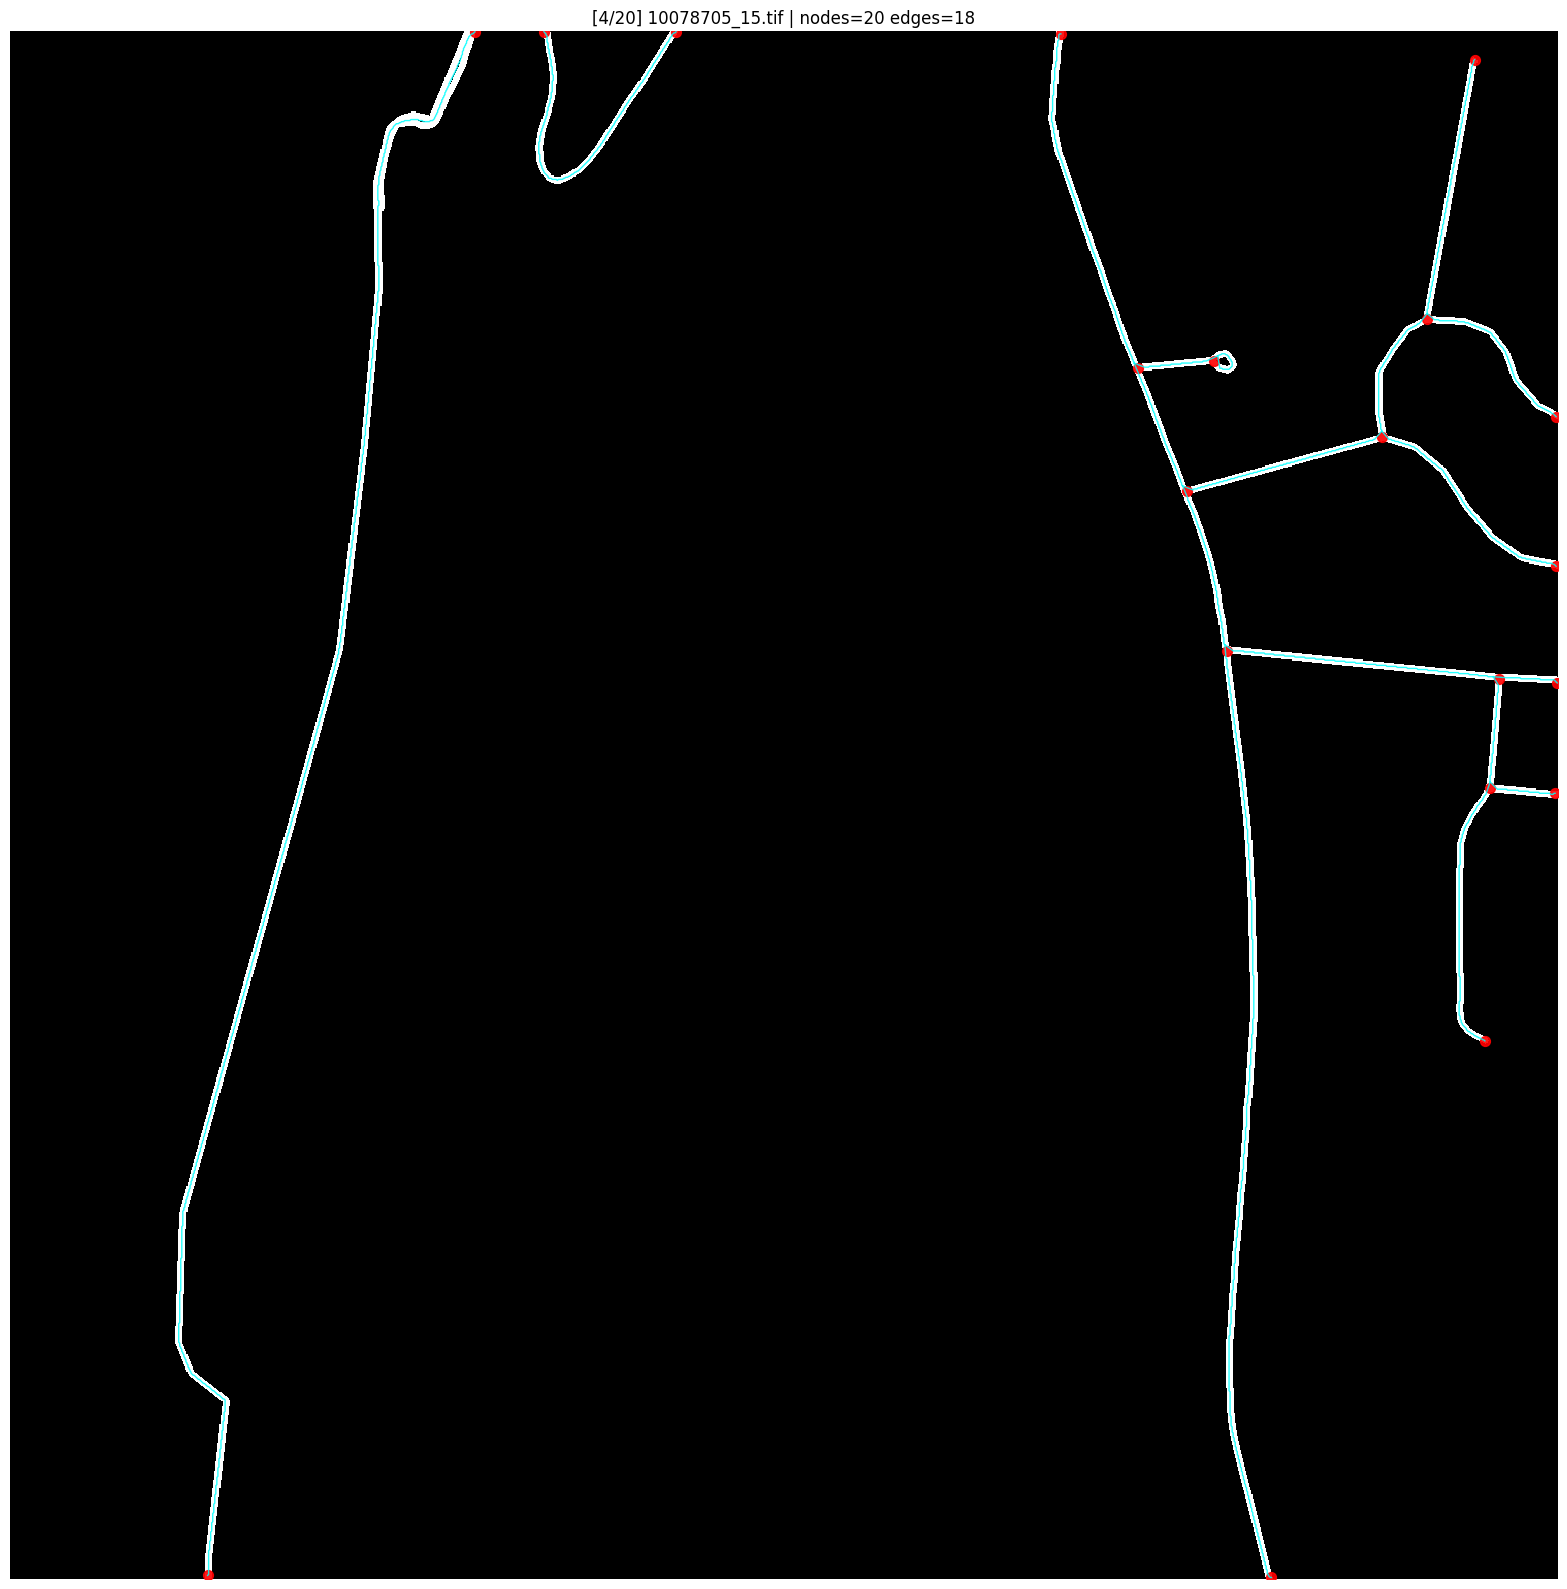

10078720_15.tif: removed=1, filled_holes=5, nodes=20, edges=17


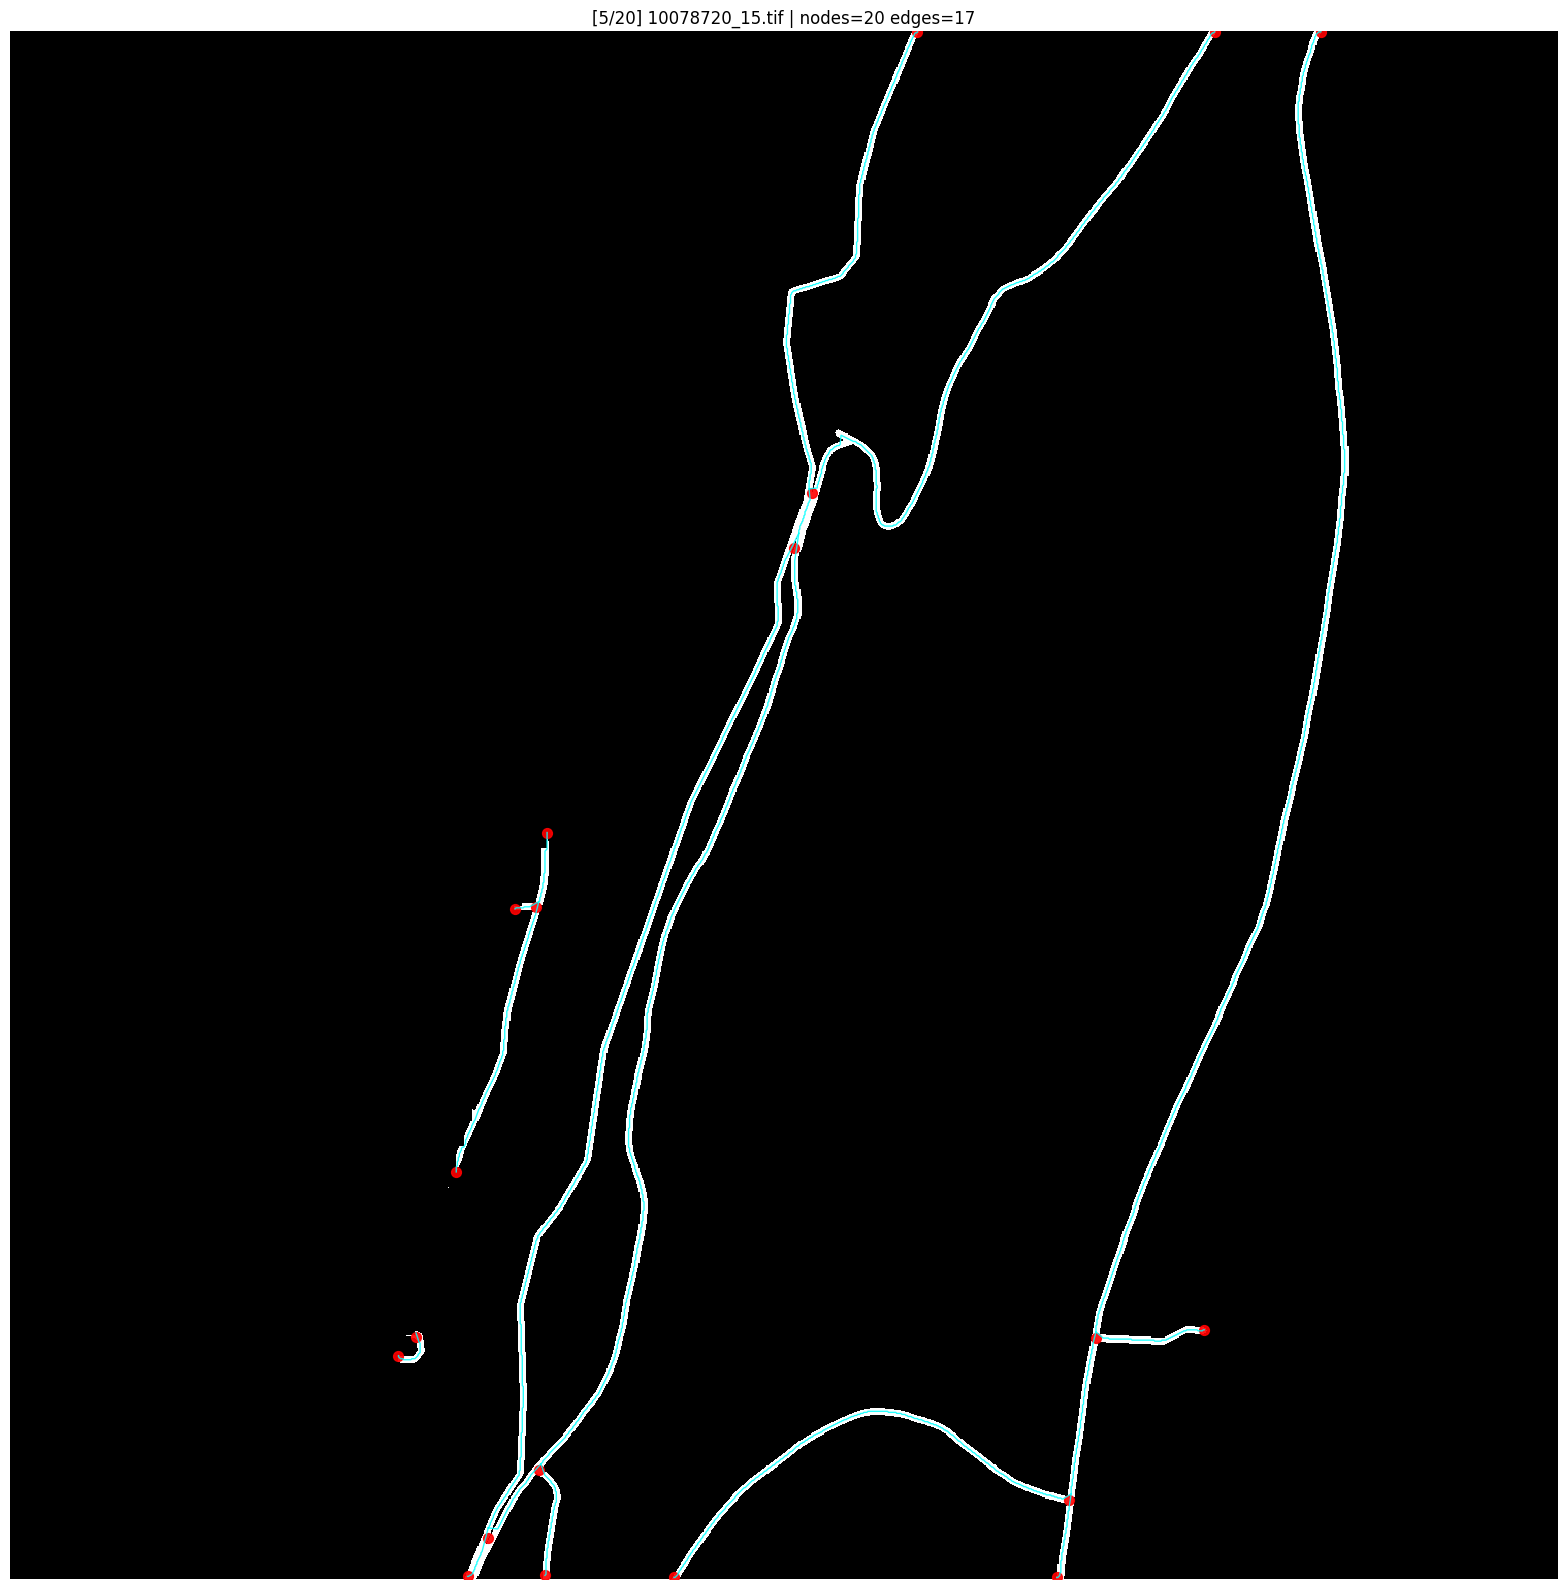

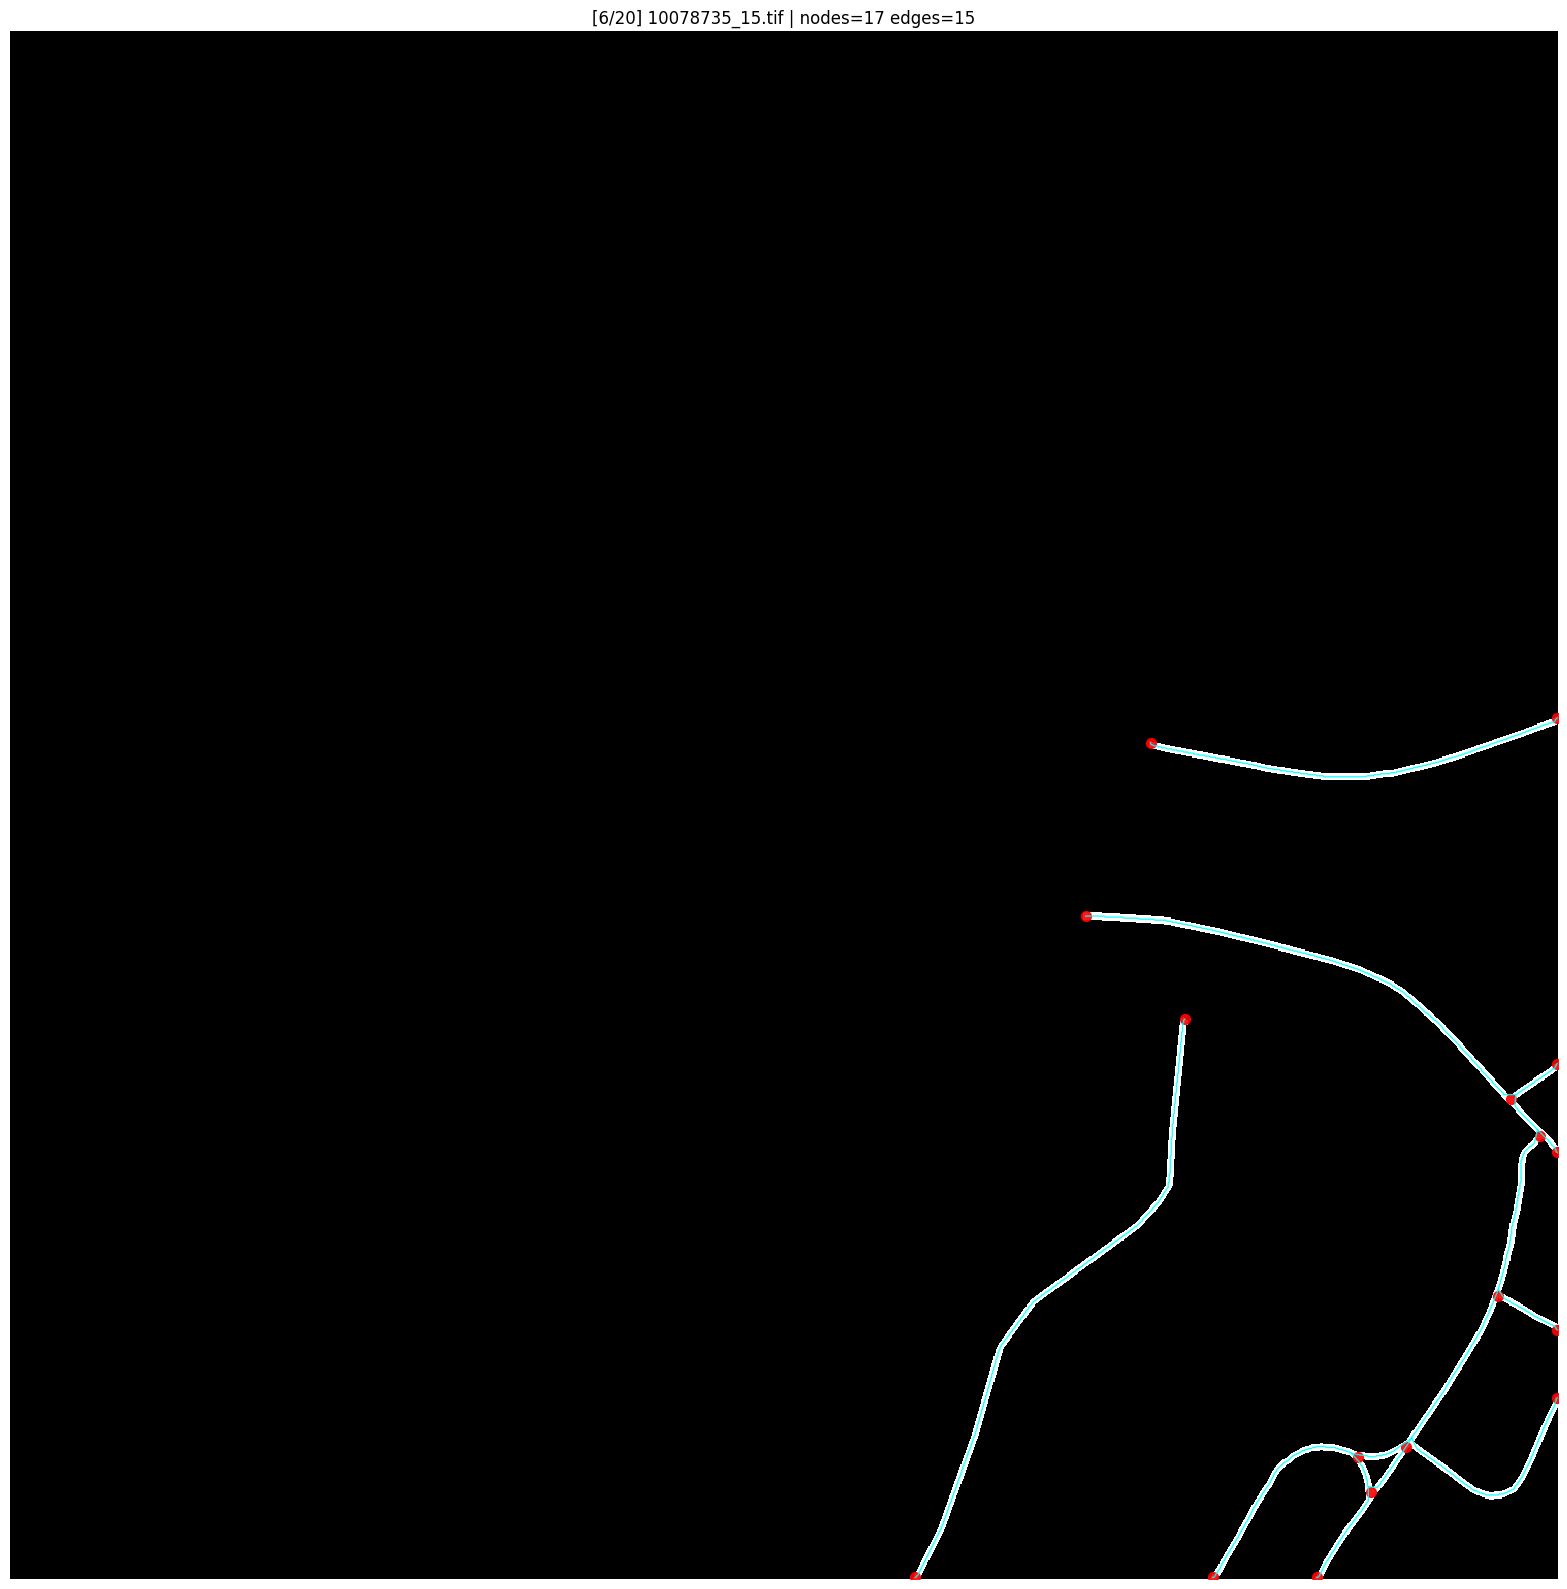

10078750_15.tif: removed=1, filled_holes=0, nodes=0, edges=0


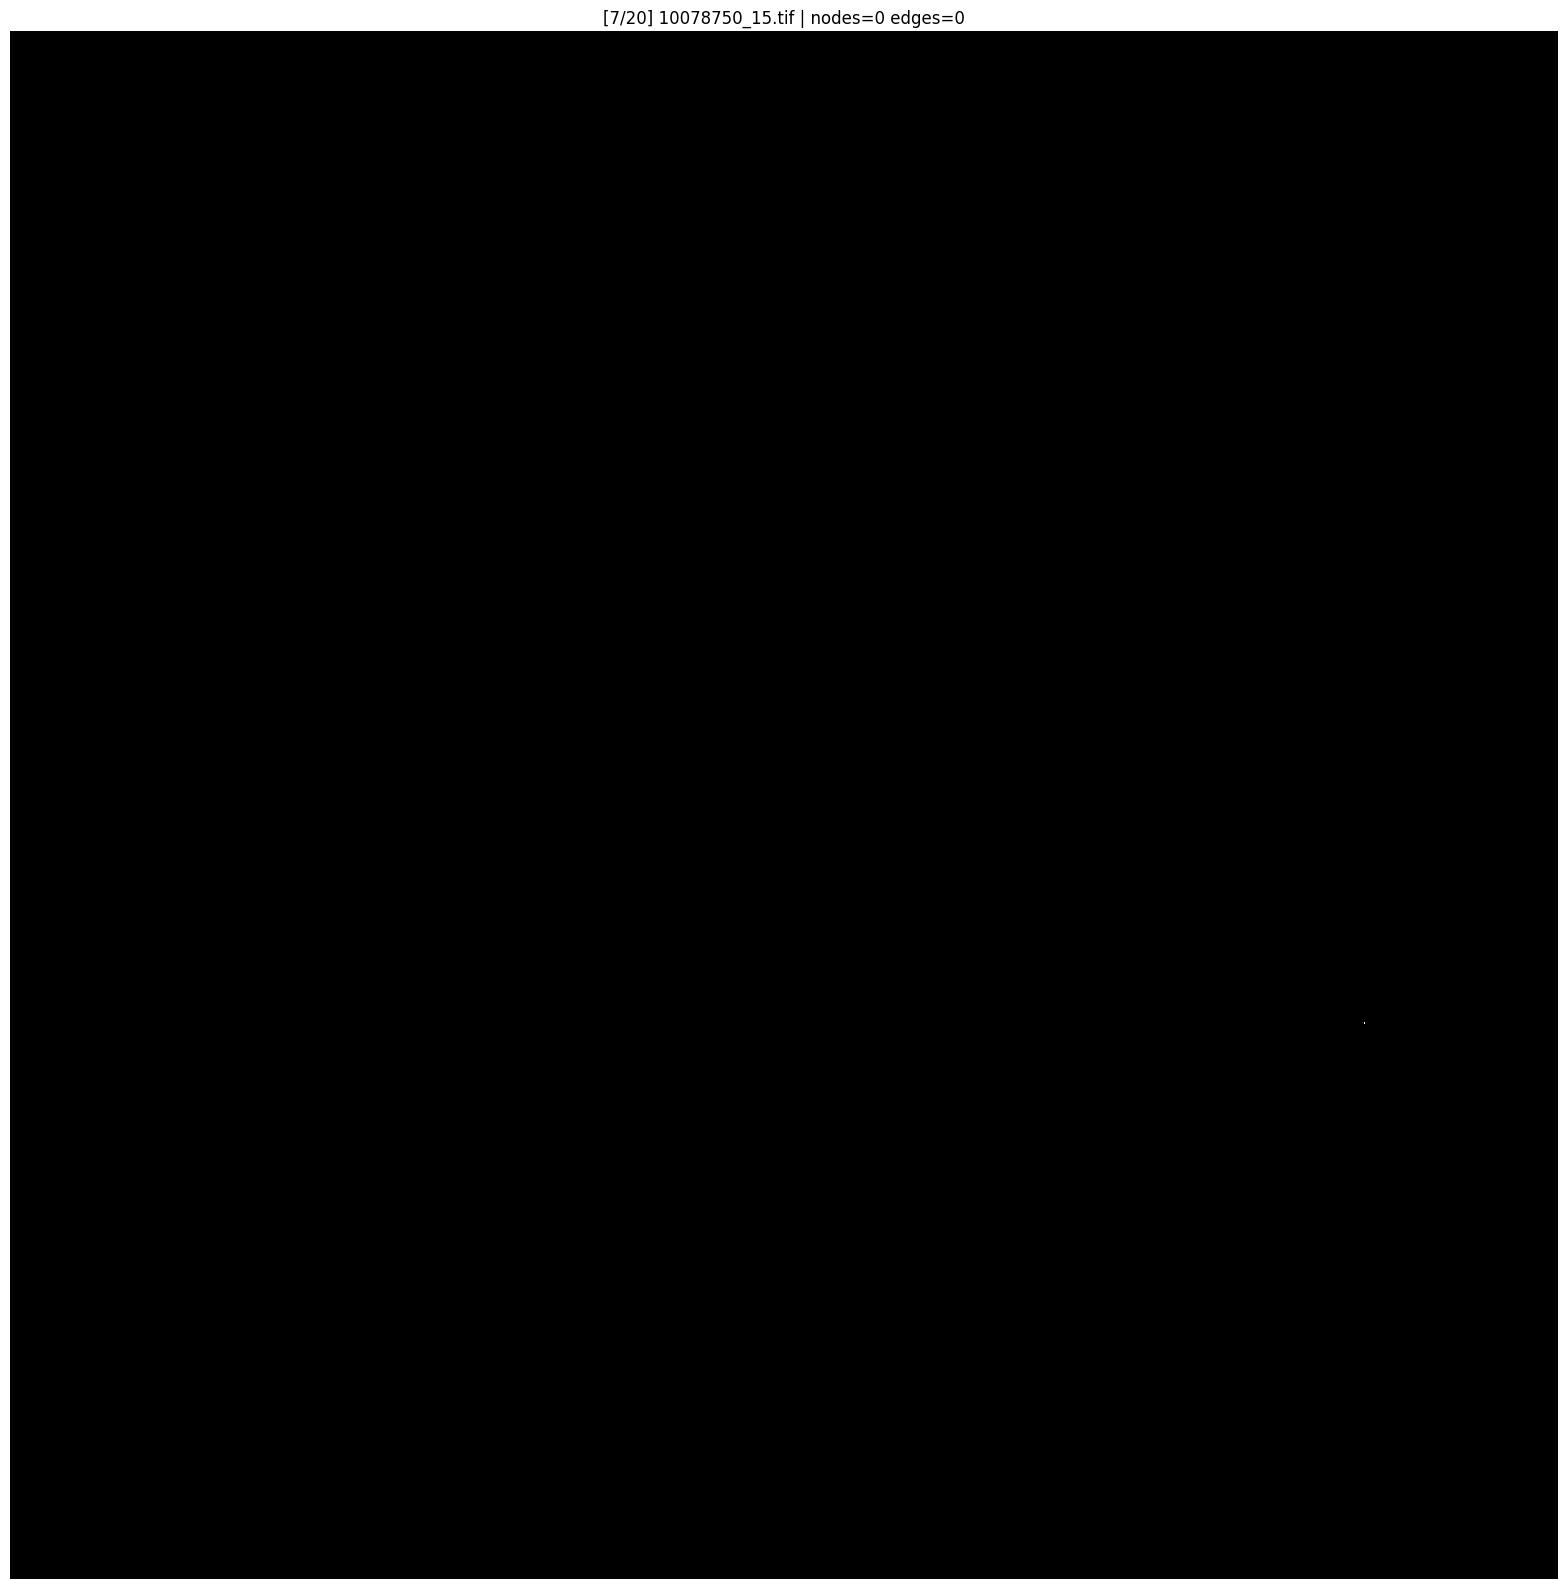

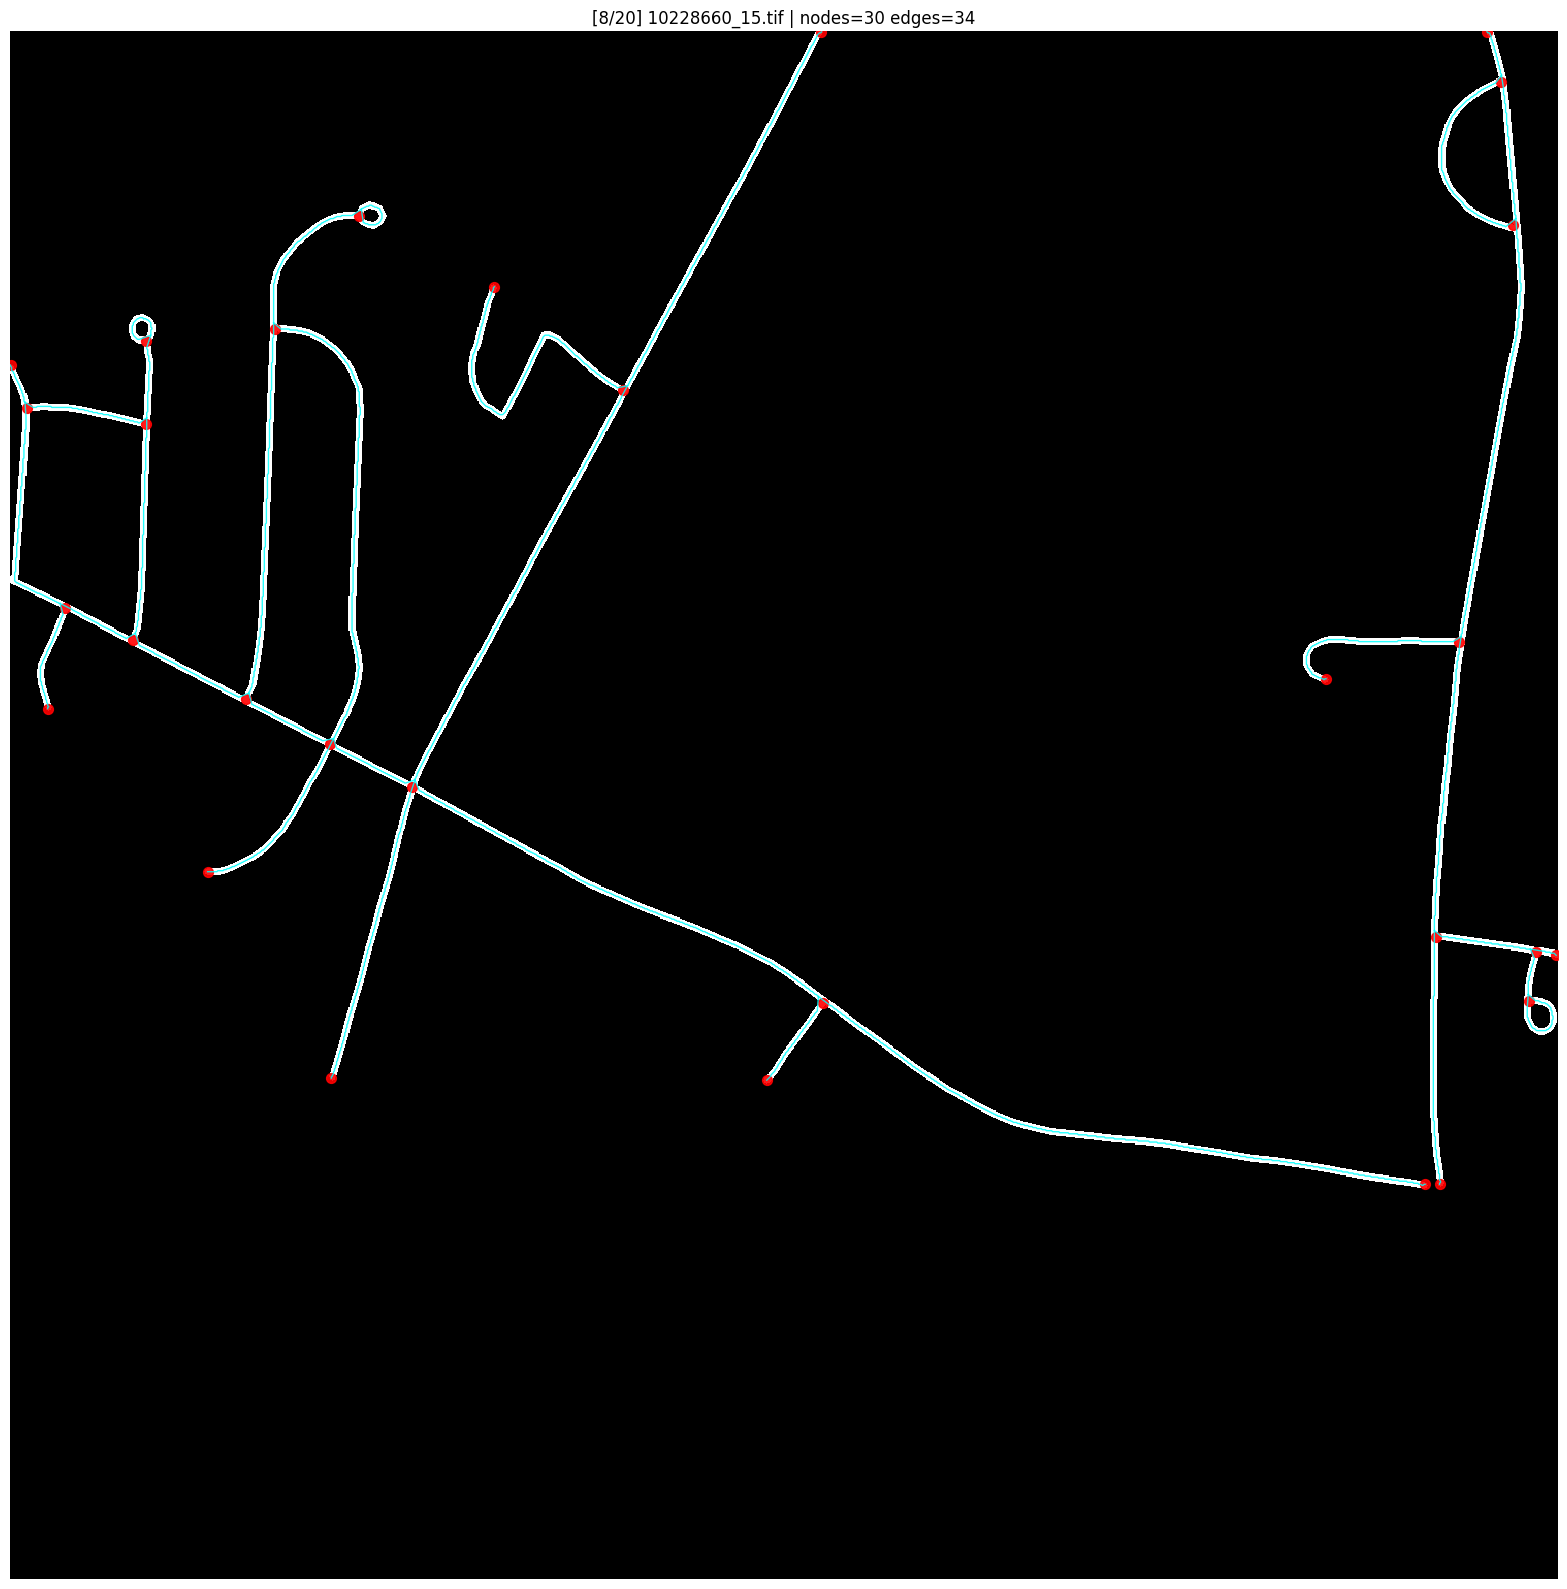

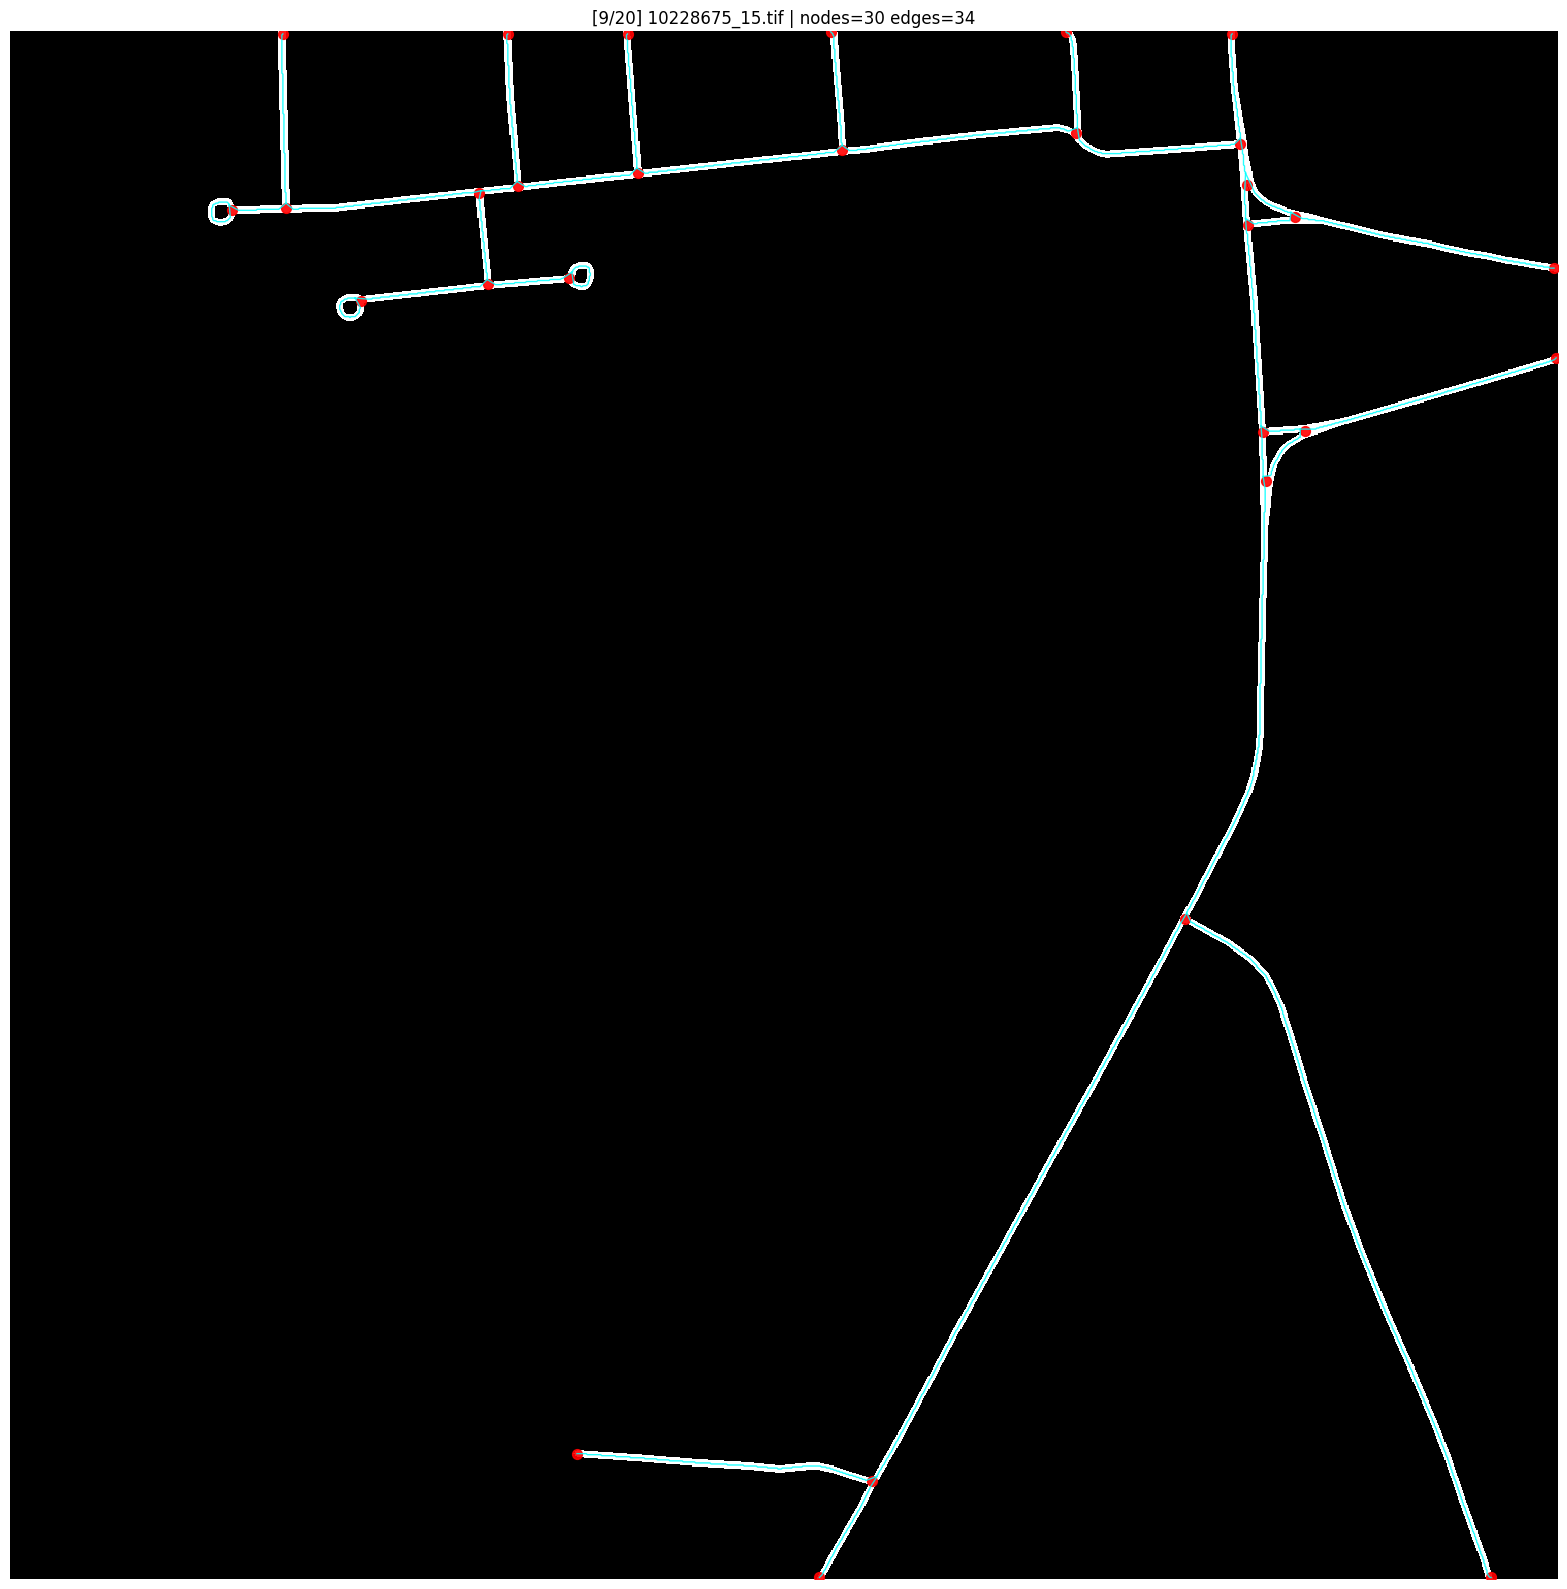

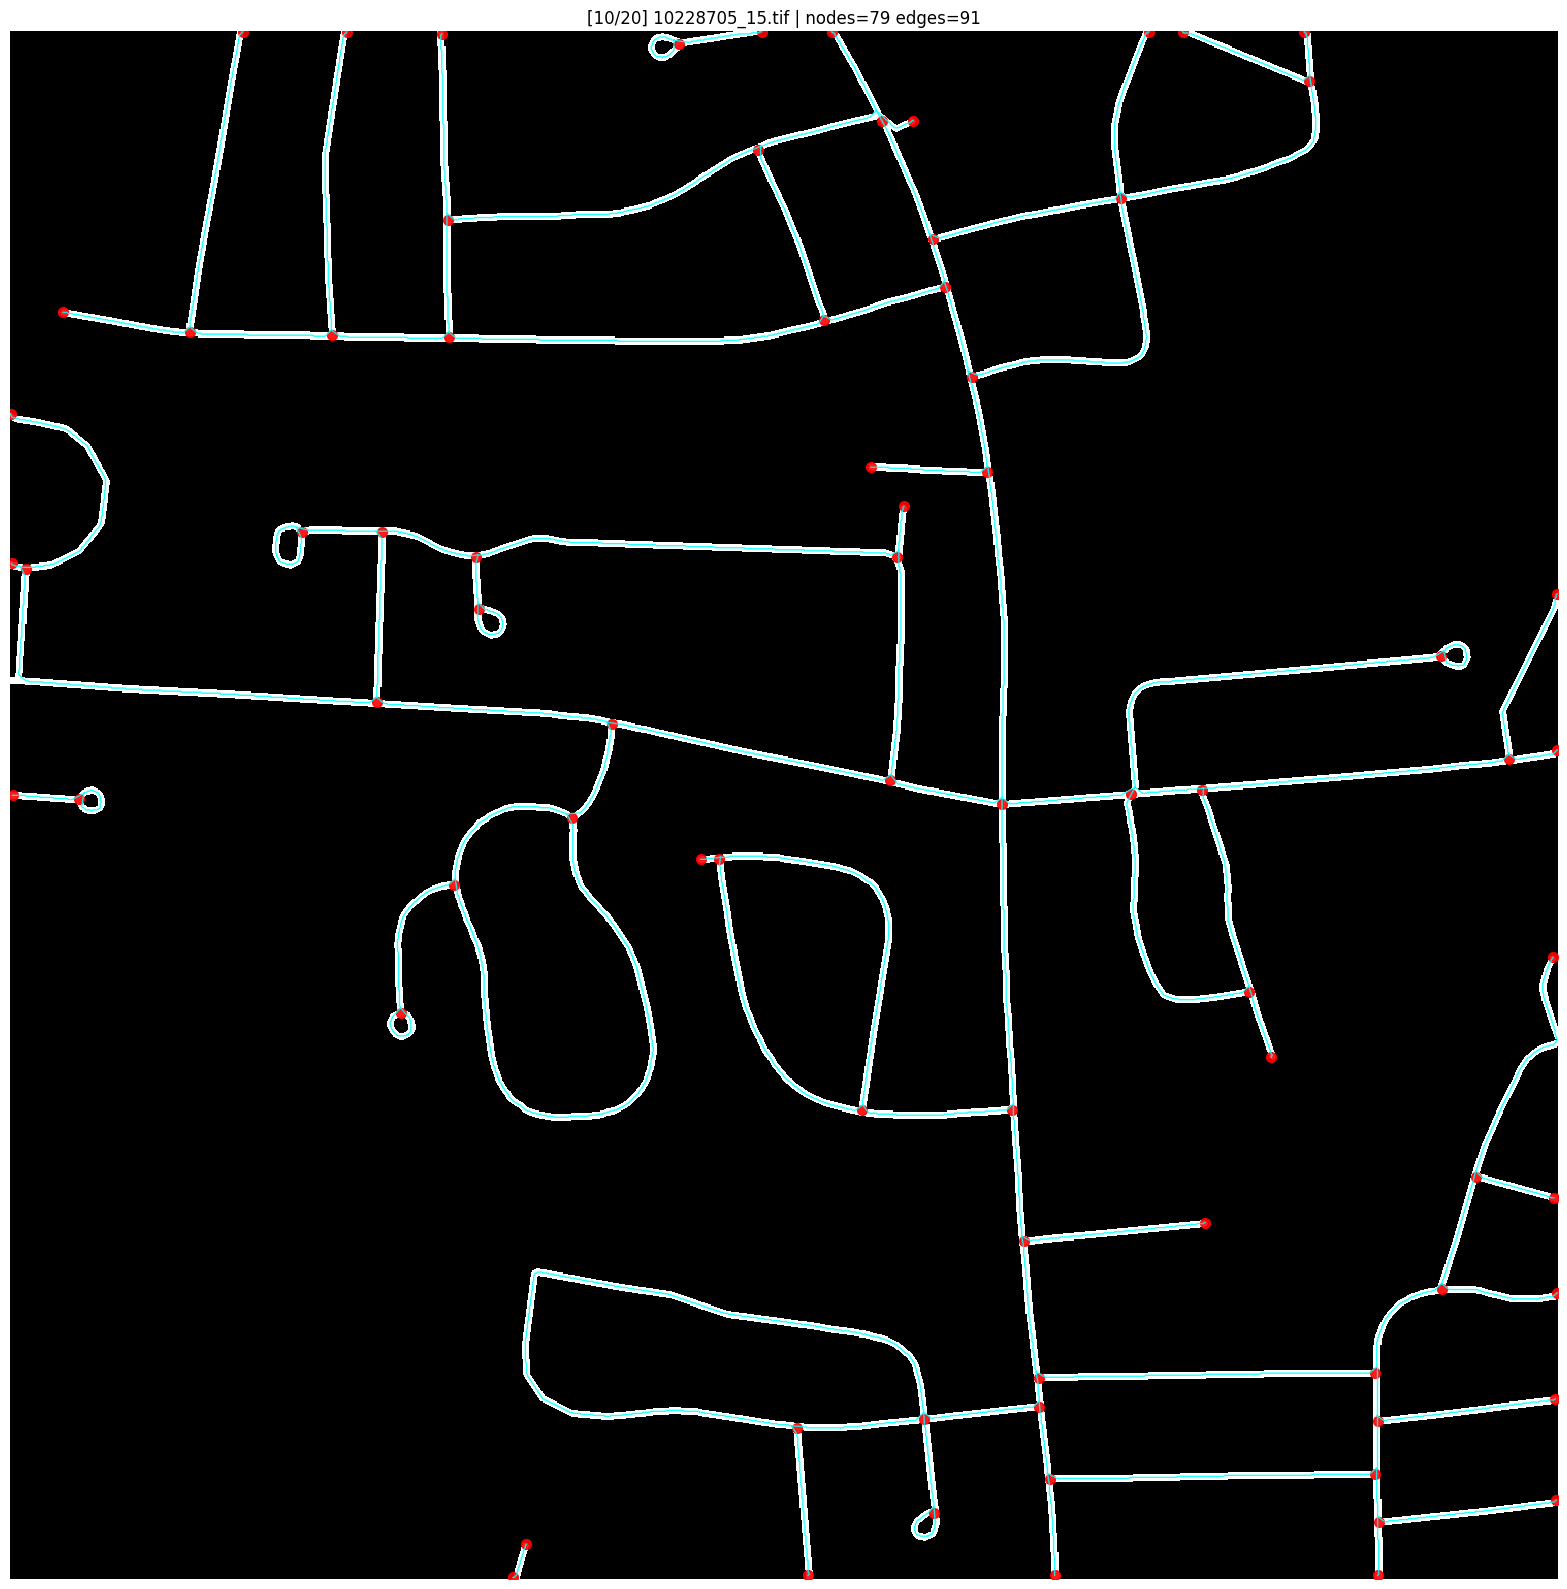

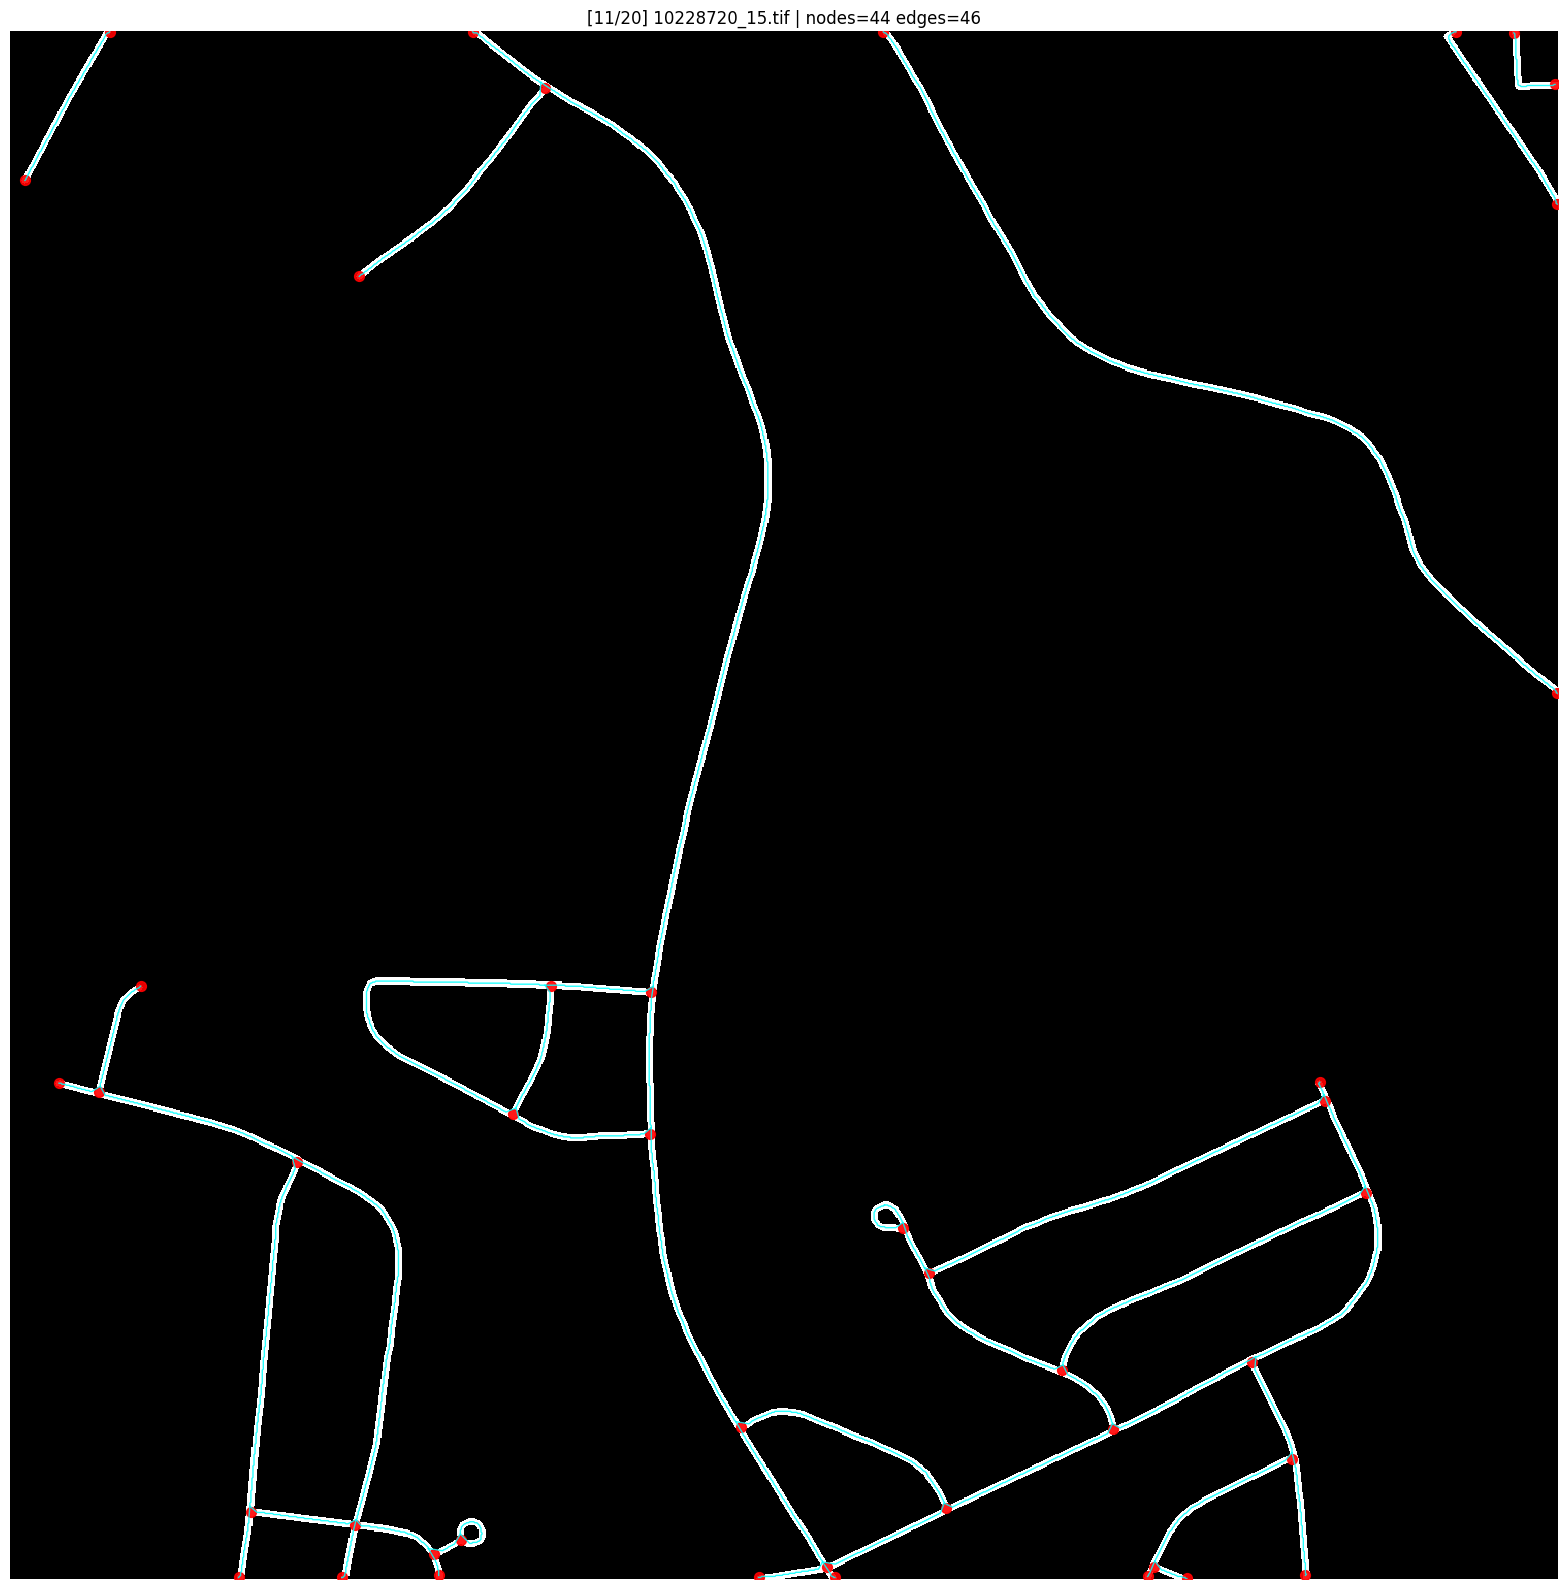

10228735_15.tif: removed=0, filled_holes=4, nodes=61, edges=70


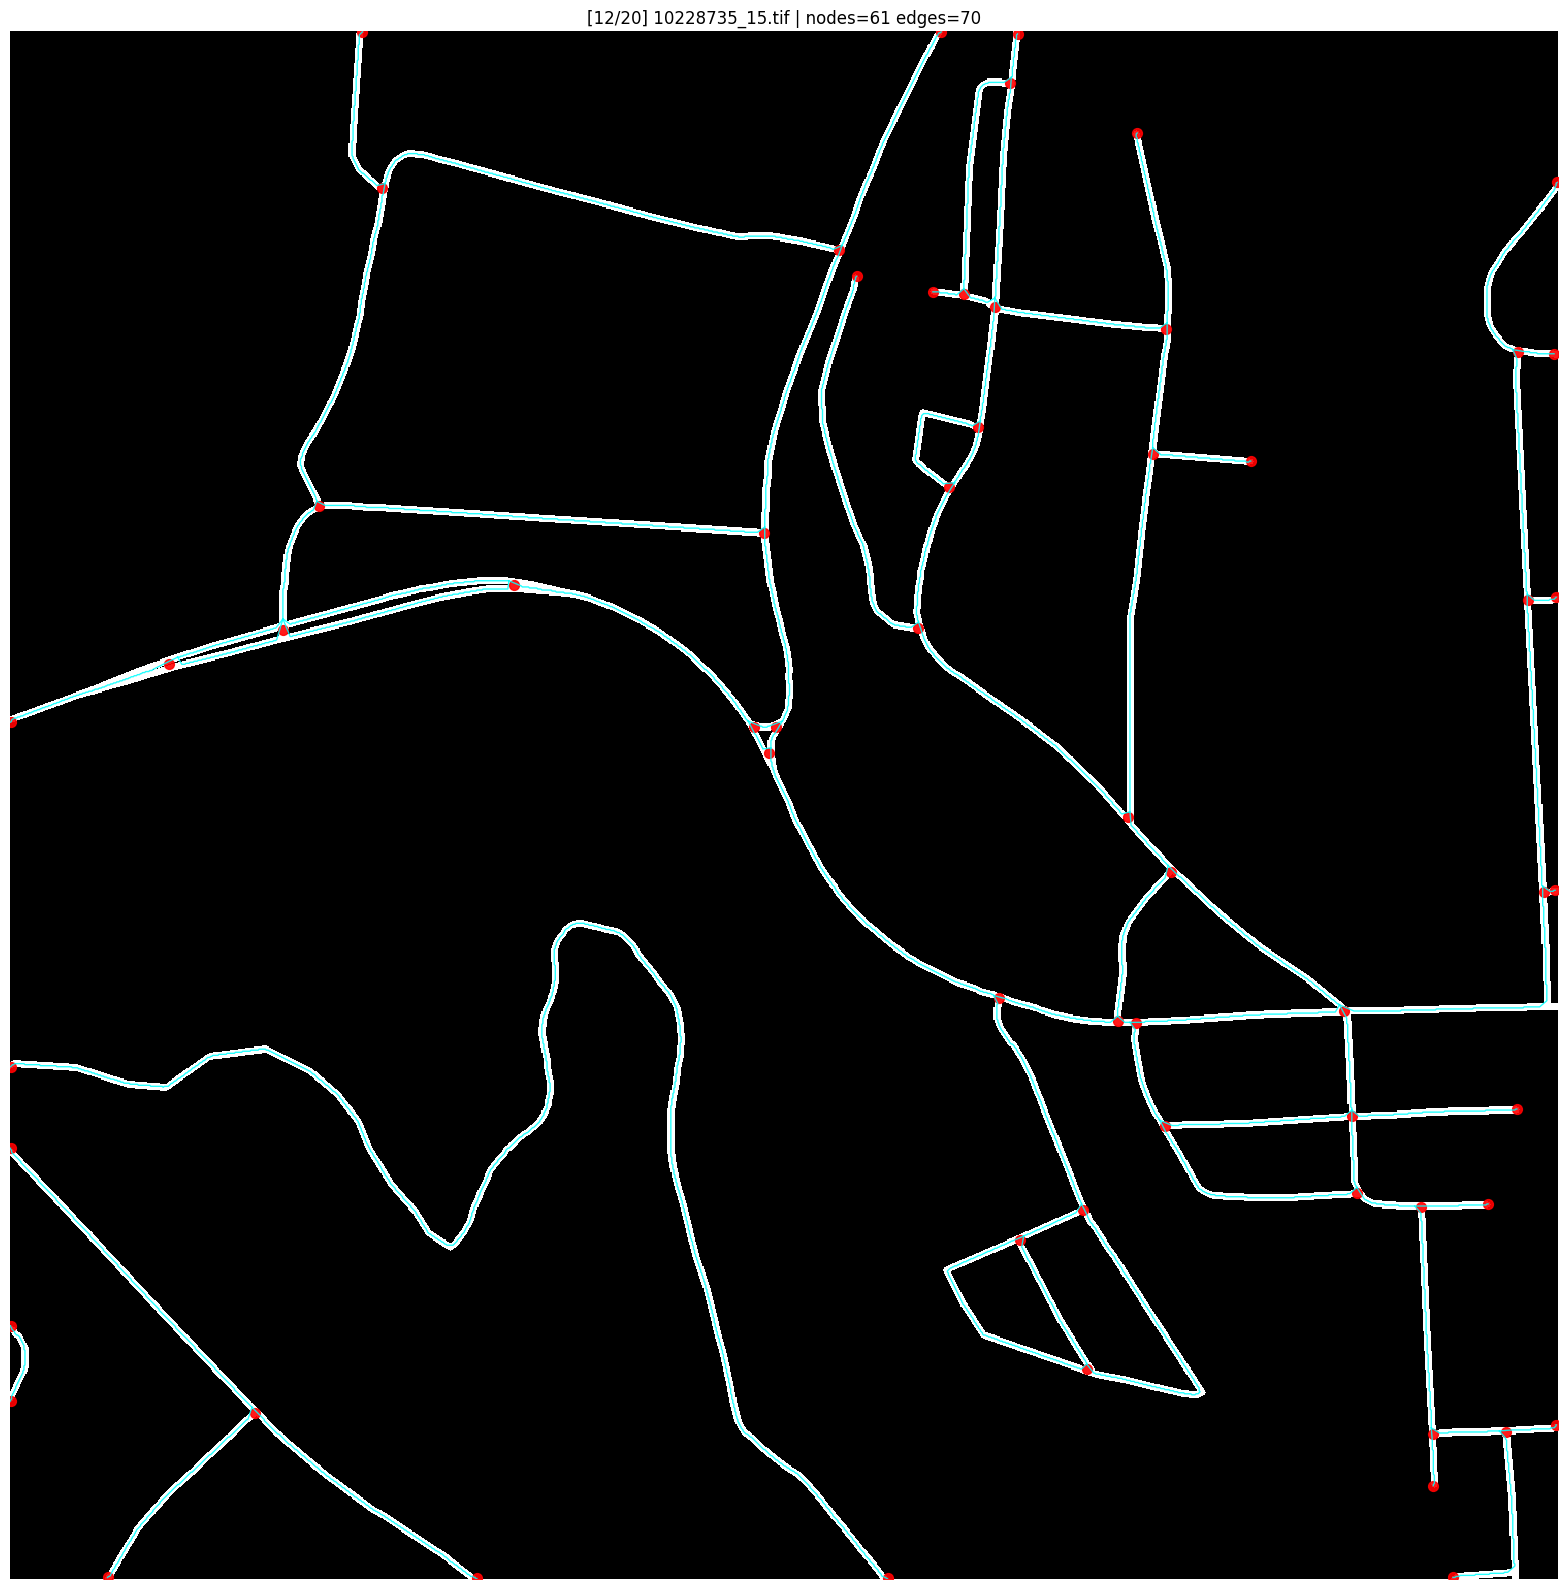

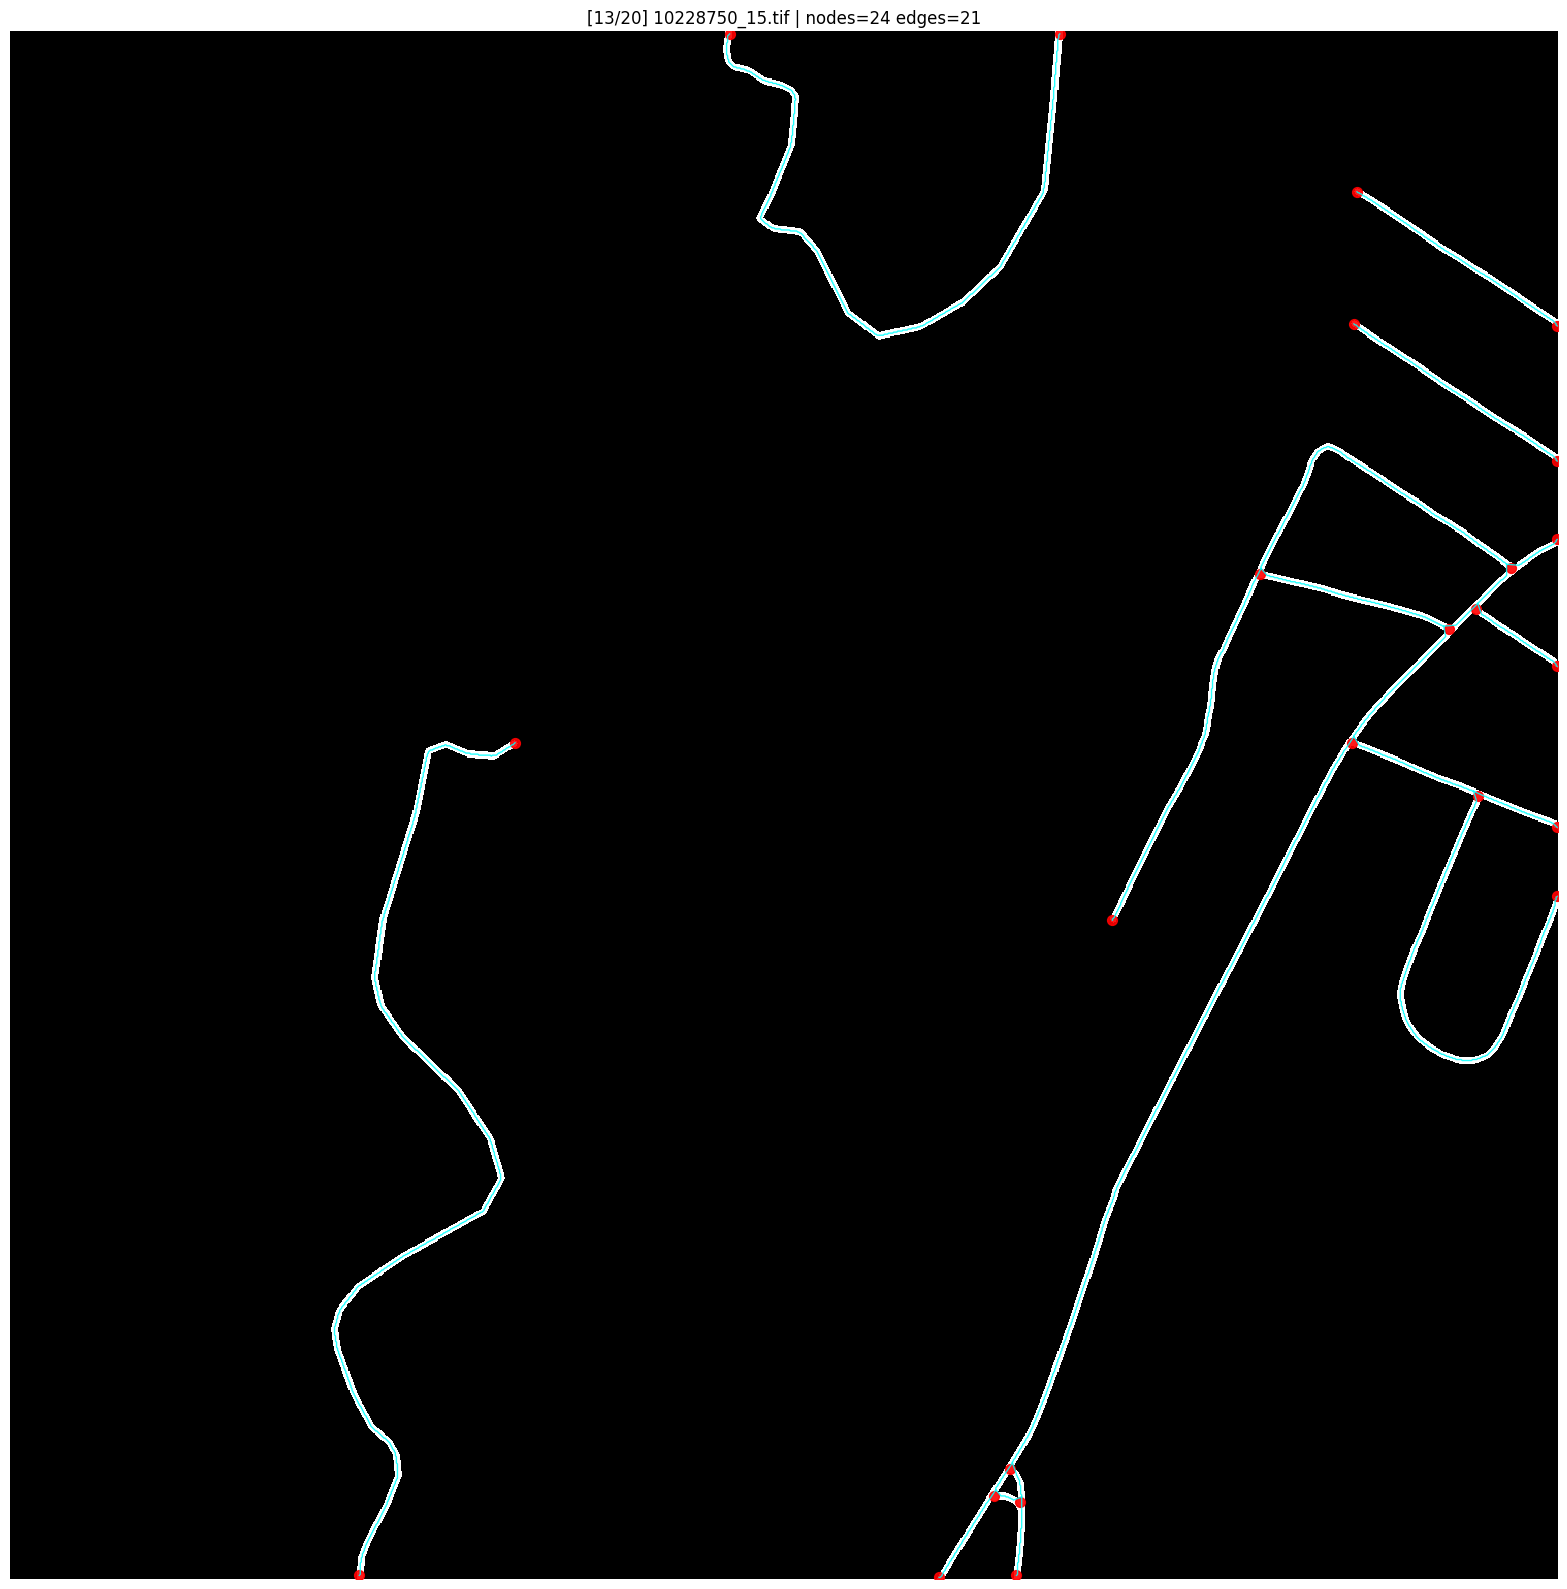

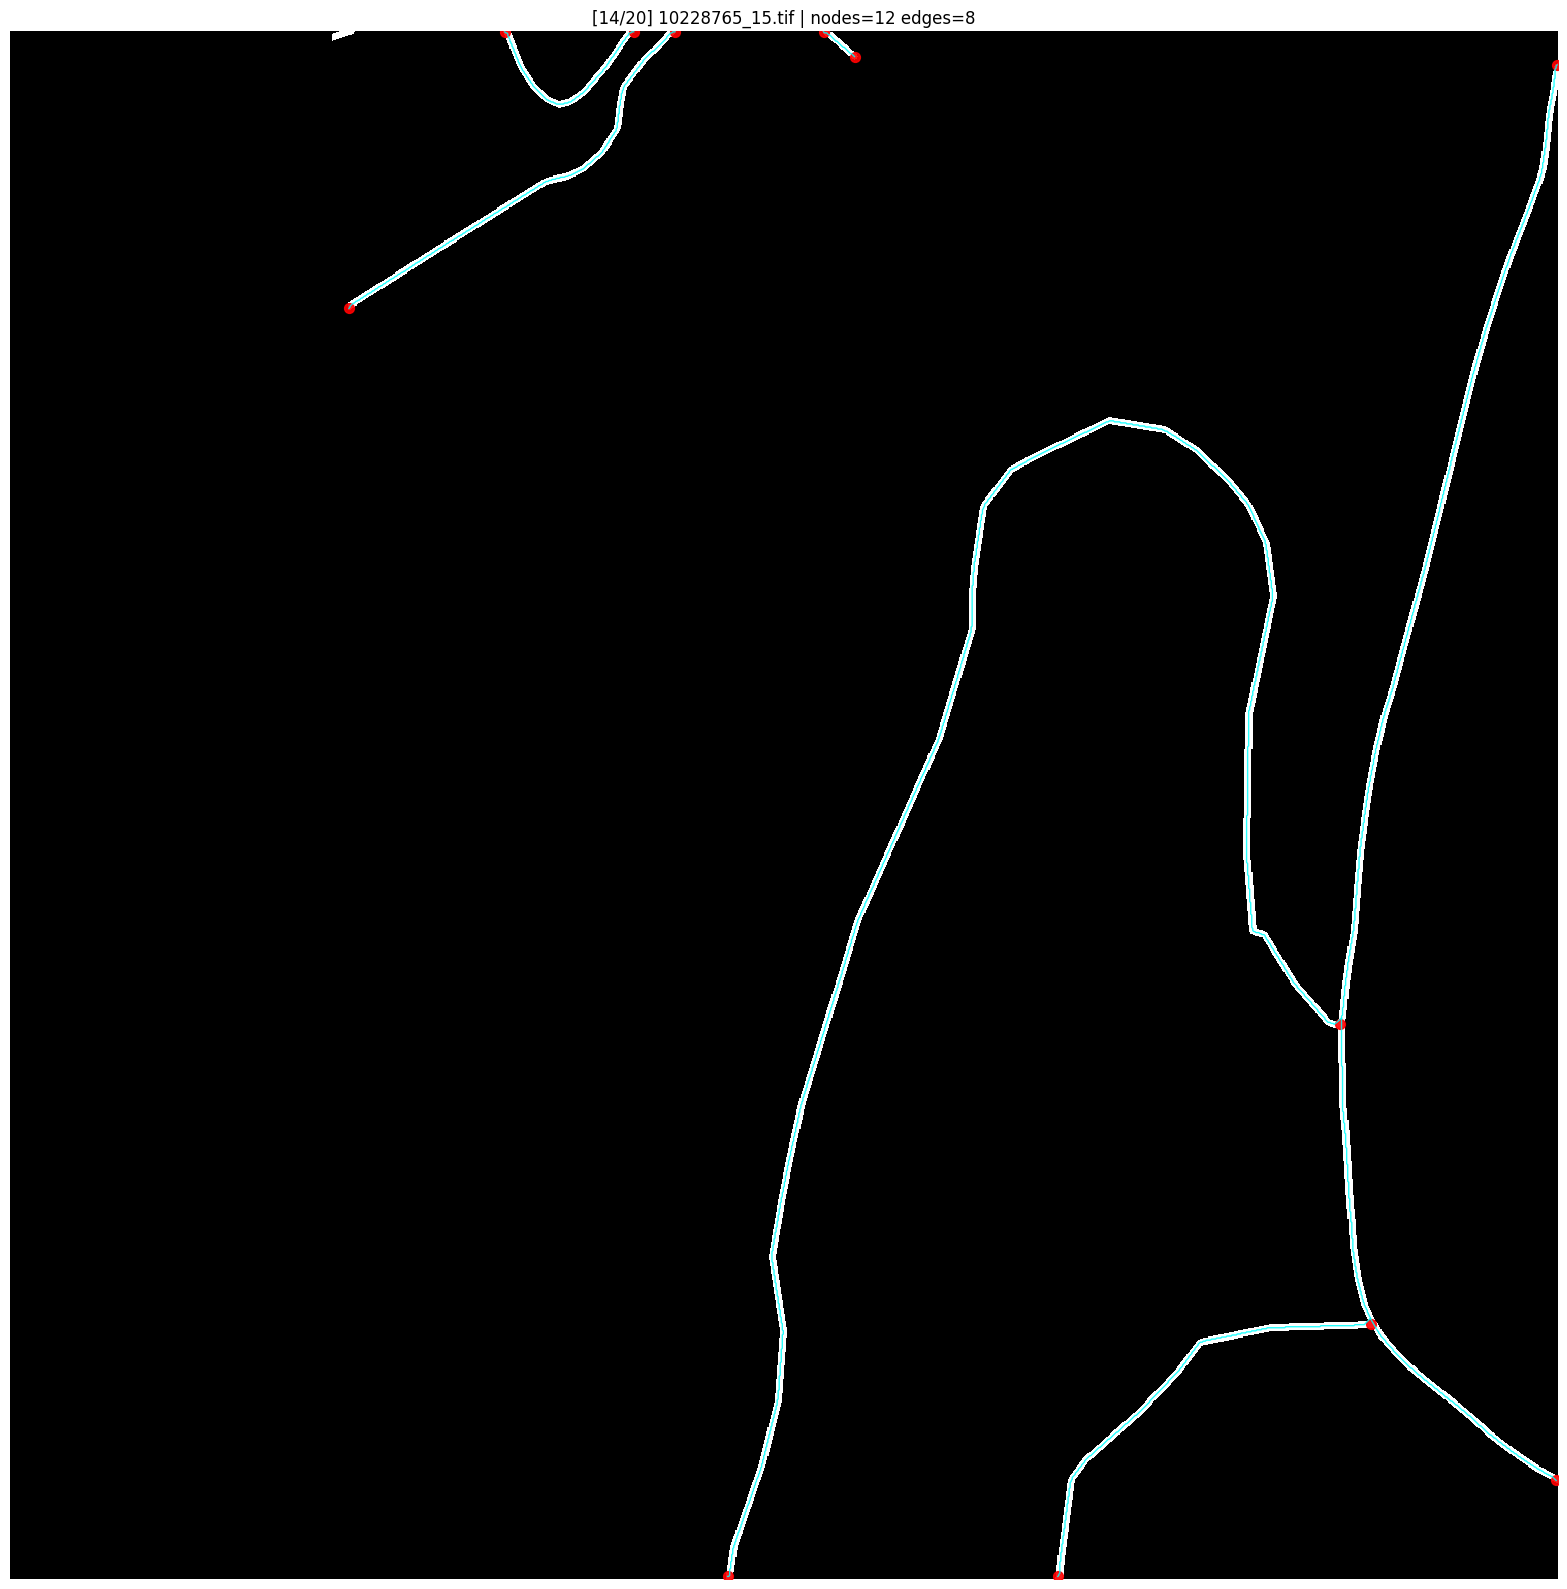

10228780_15.tif: removed=1, filled_holes=0, nodes=16, edges=10


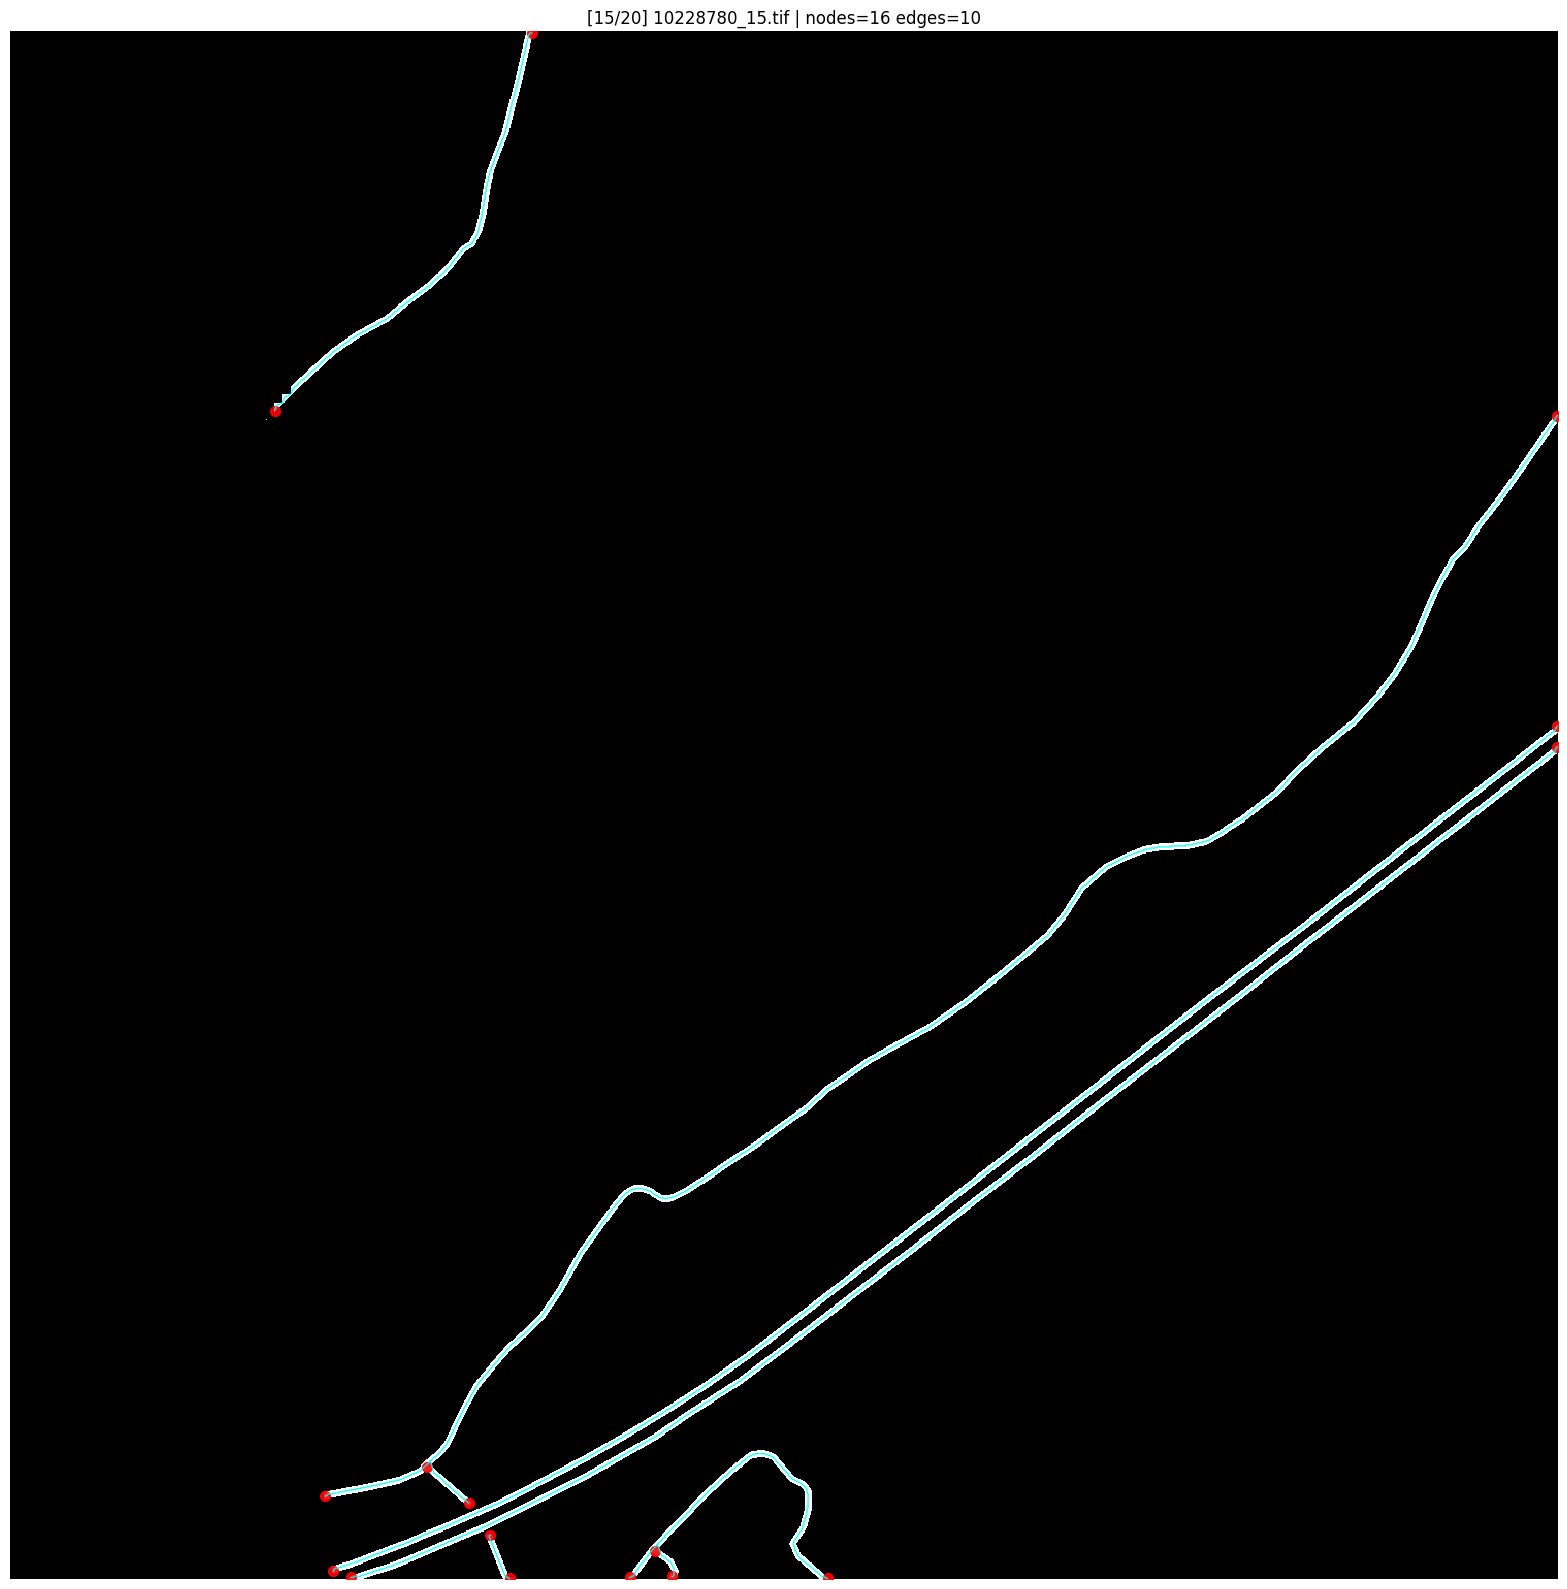

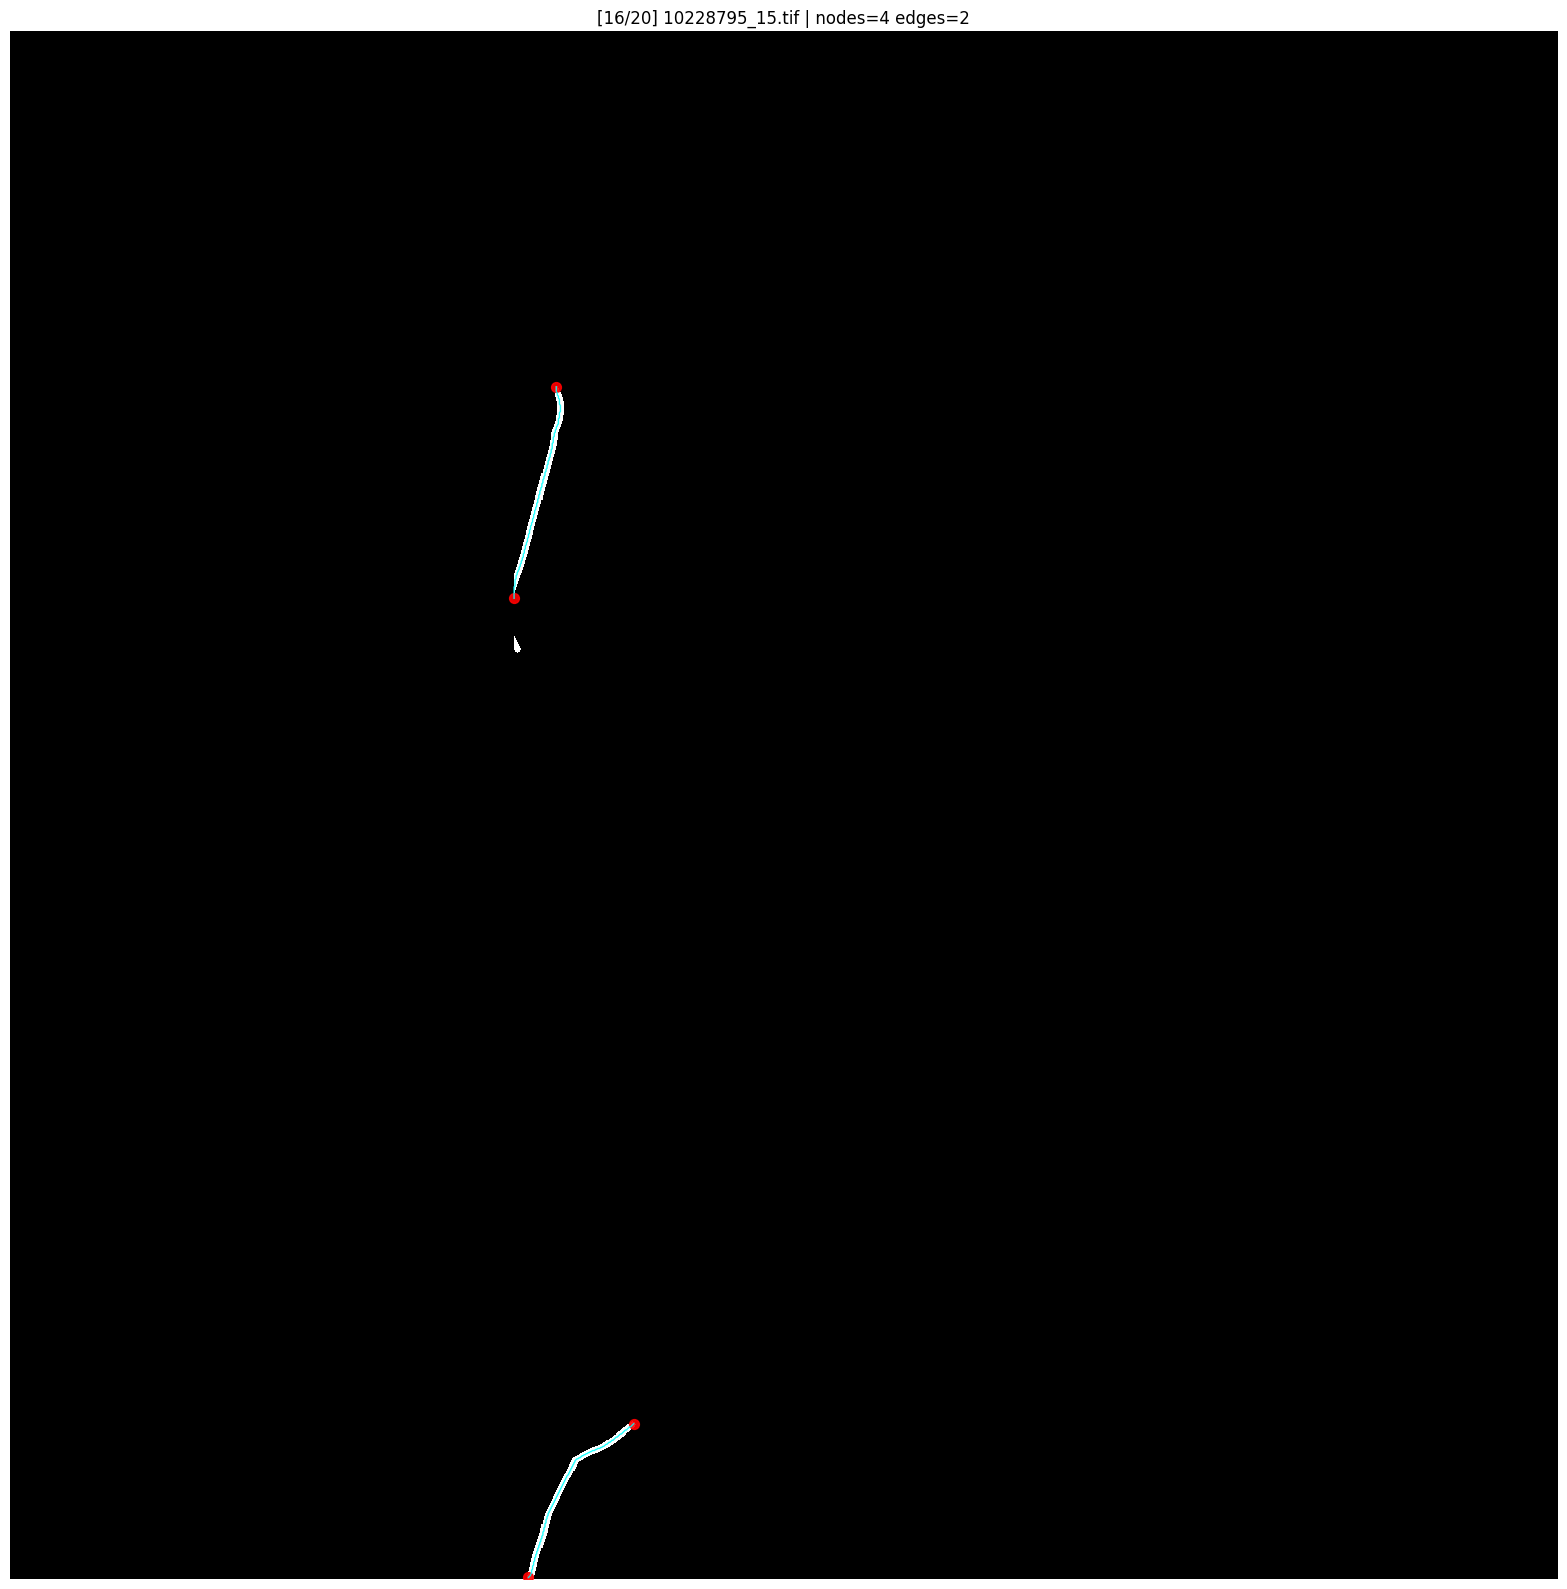

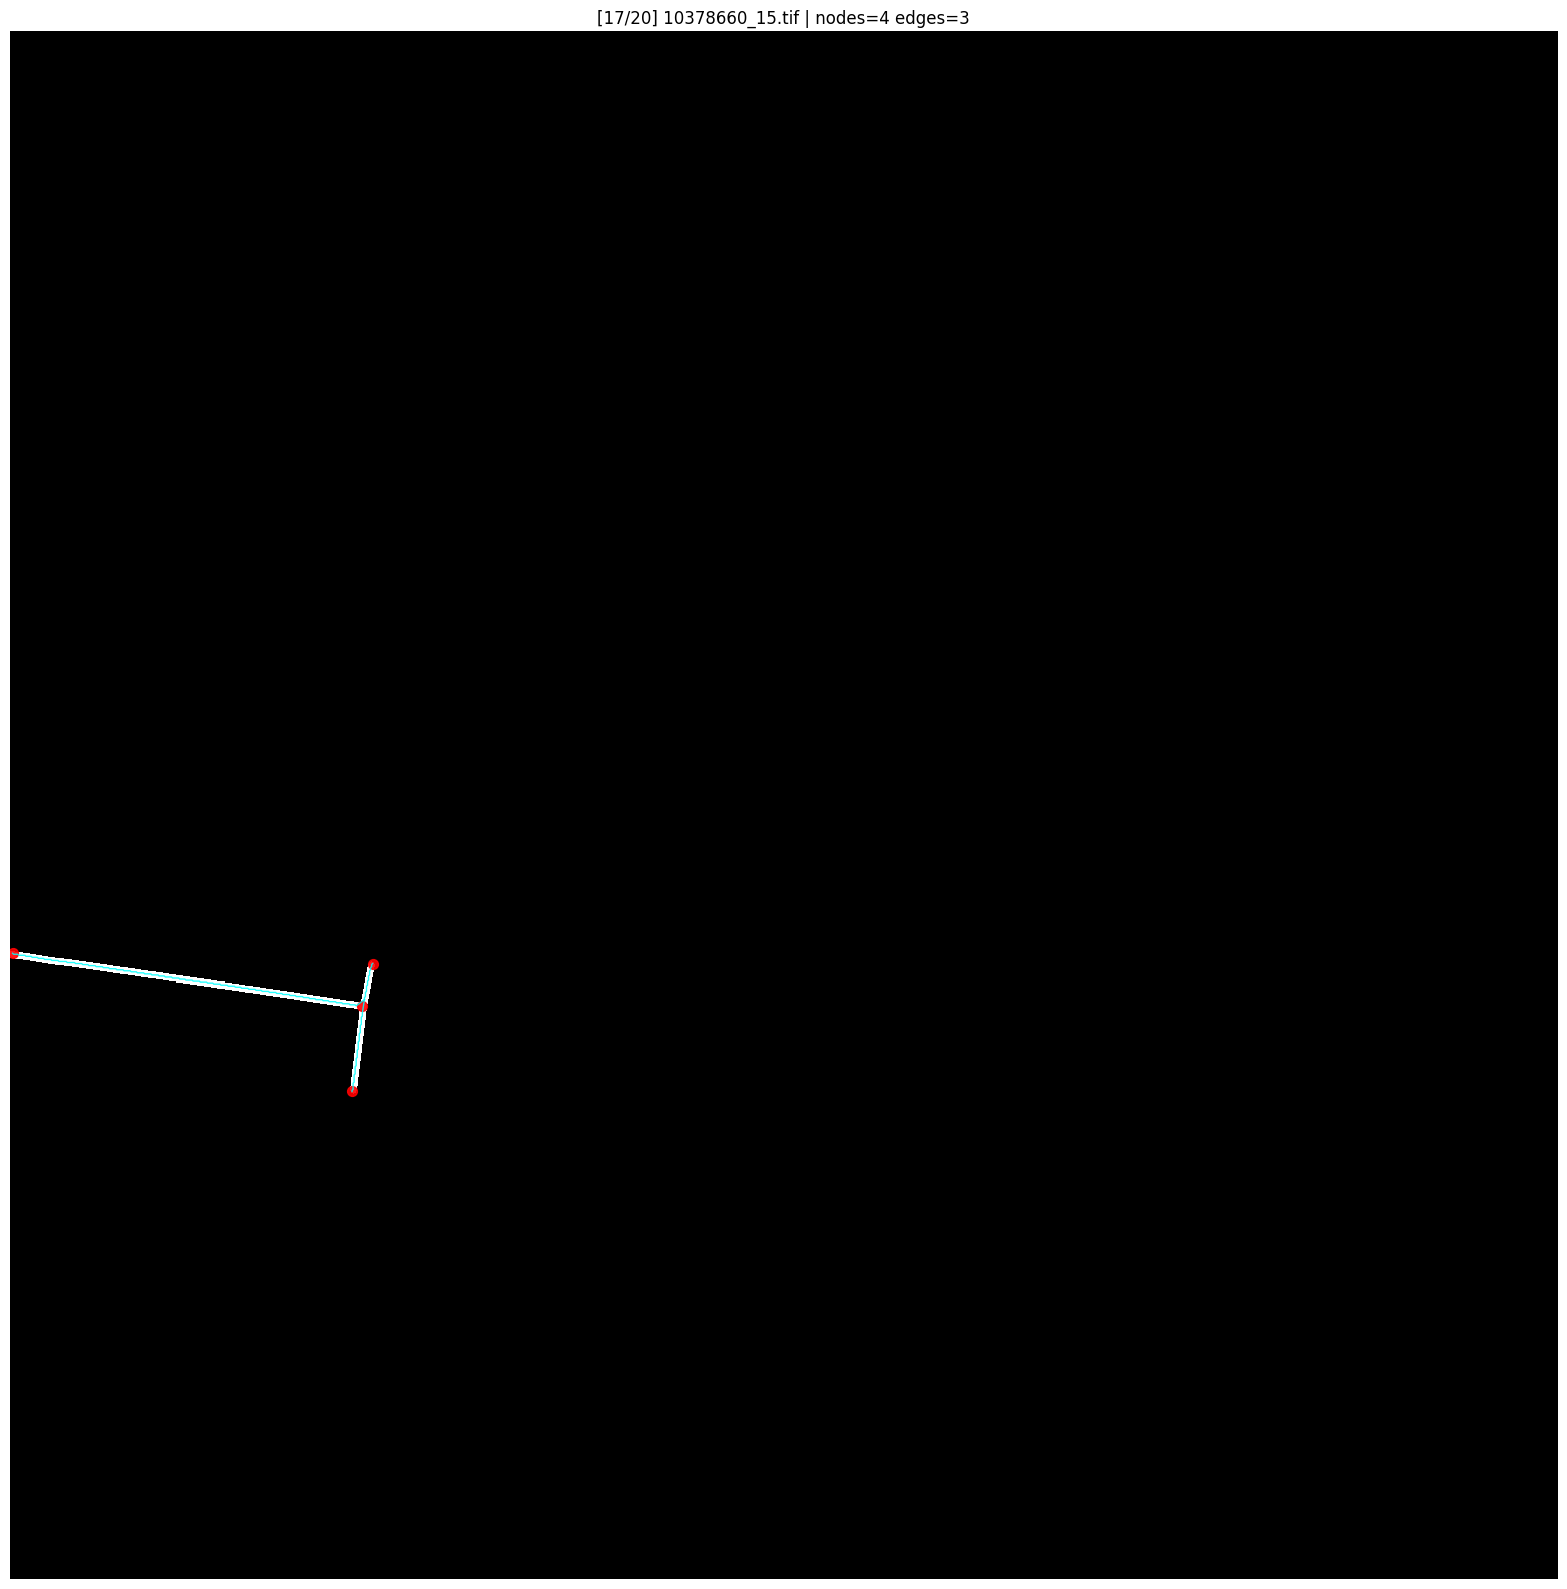

10378675_15.tif: removed=0, filled_holes=5, nodes=32, edges=32


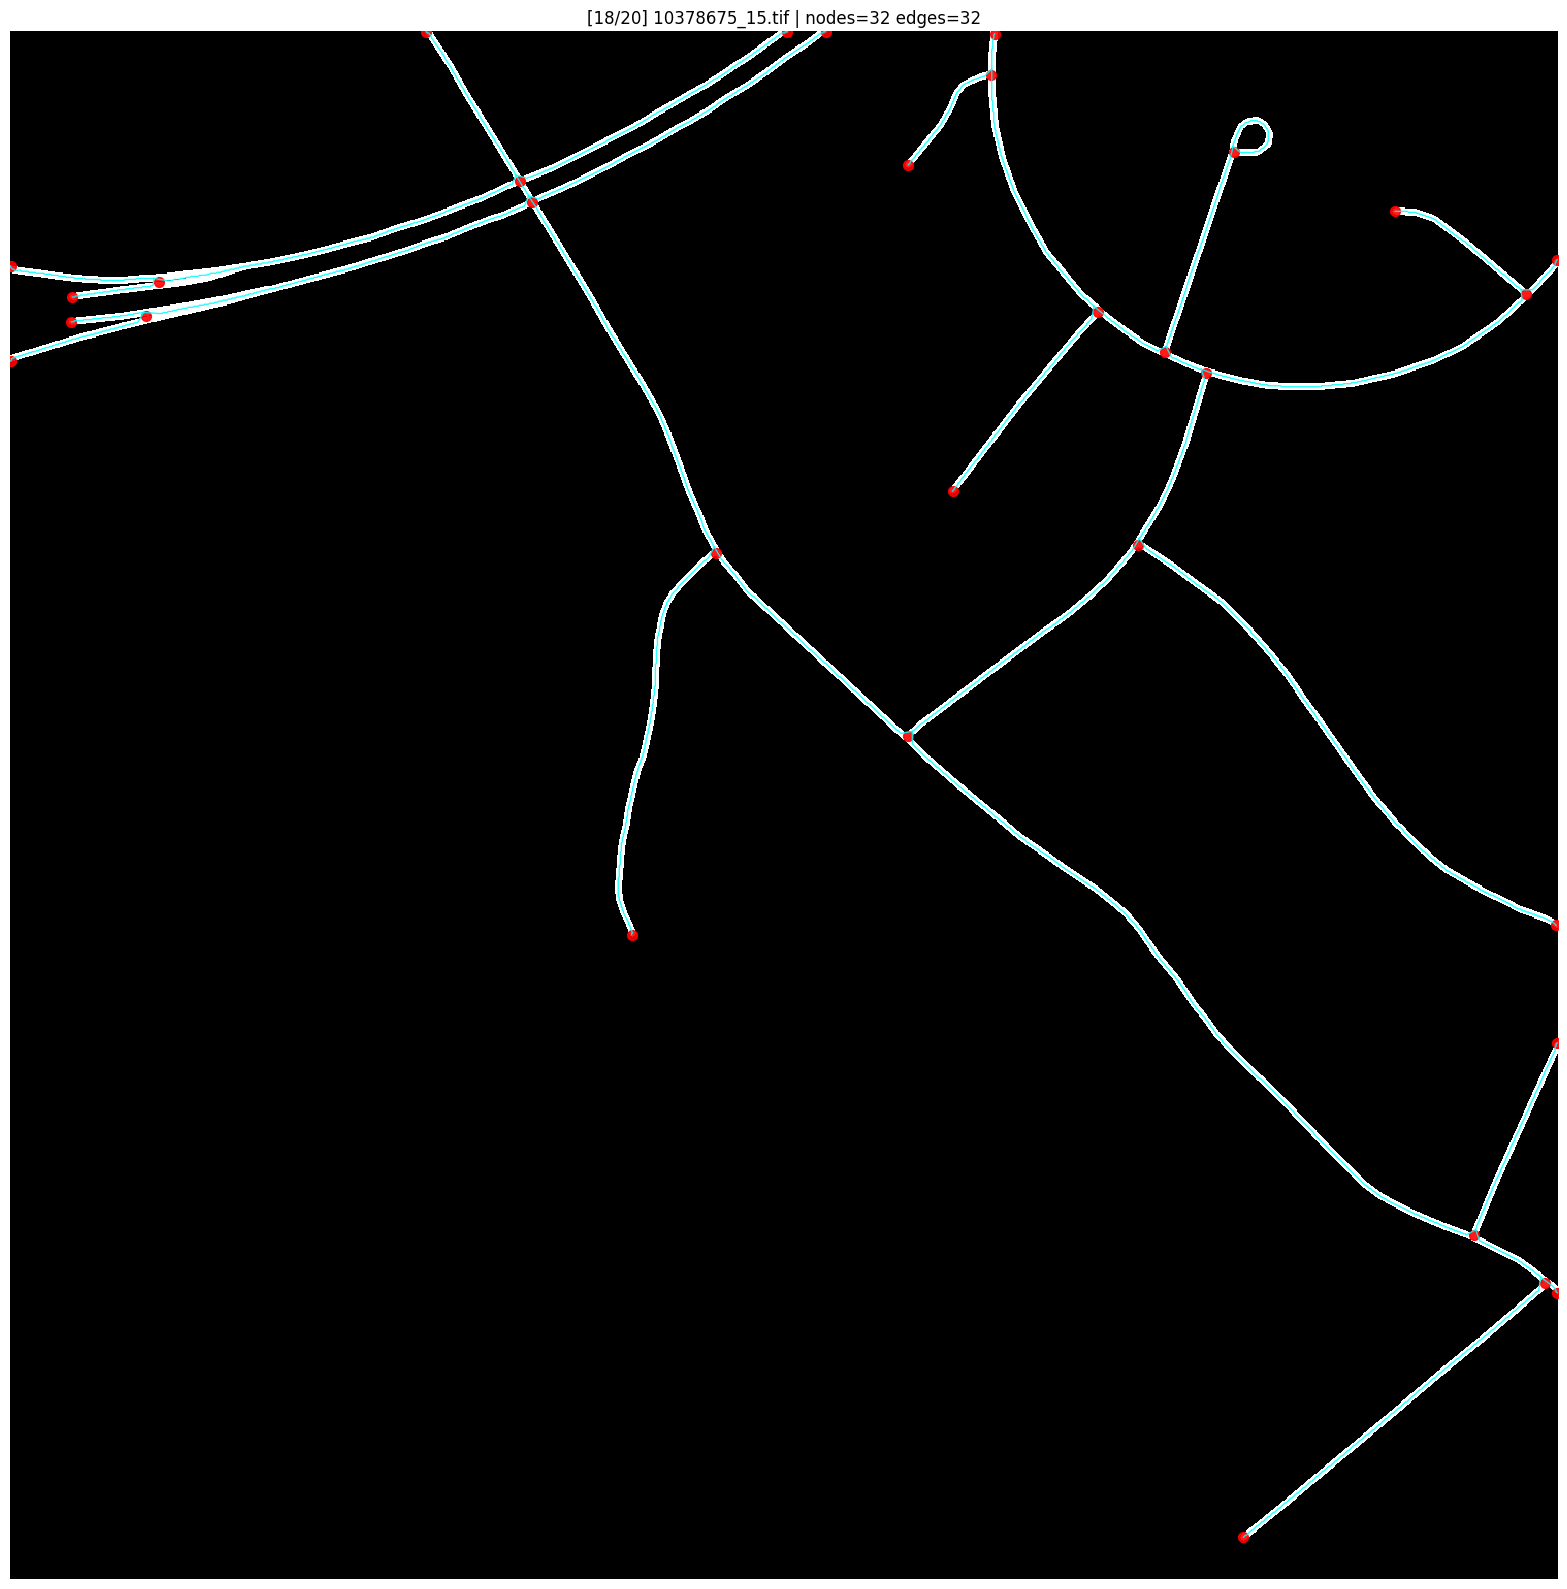

10378690_15.tif: removed=0, filled_holes=2, nodes=99, edges=114


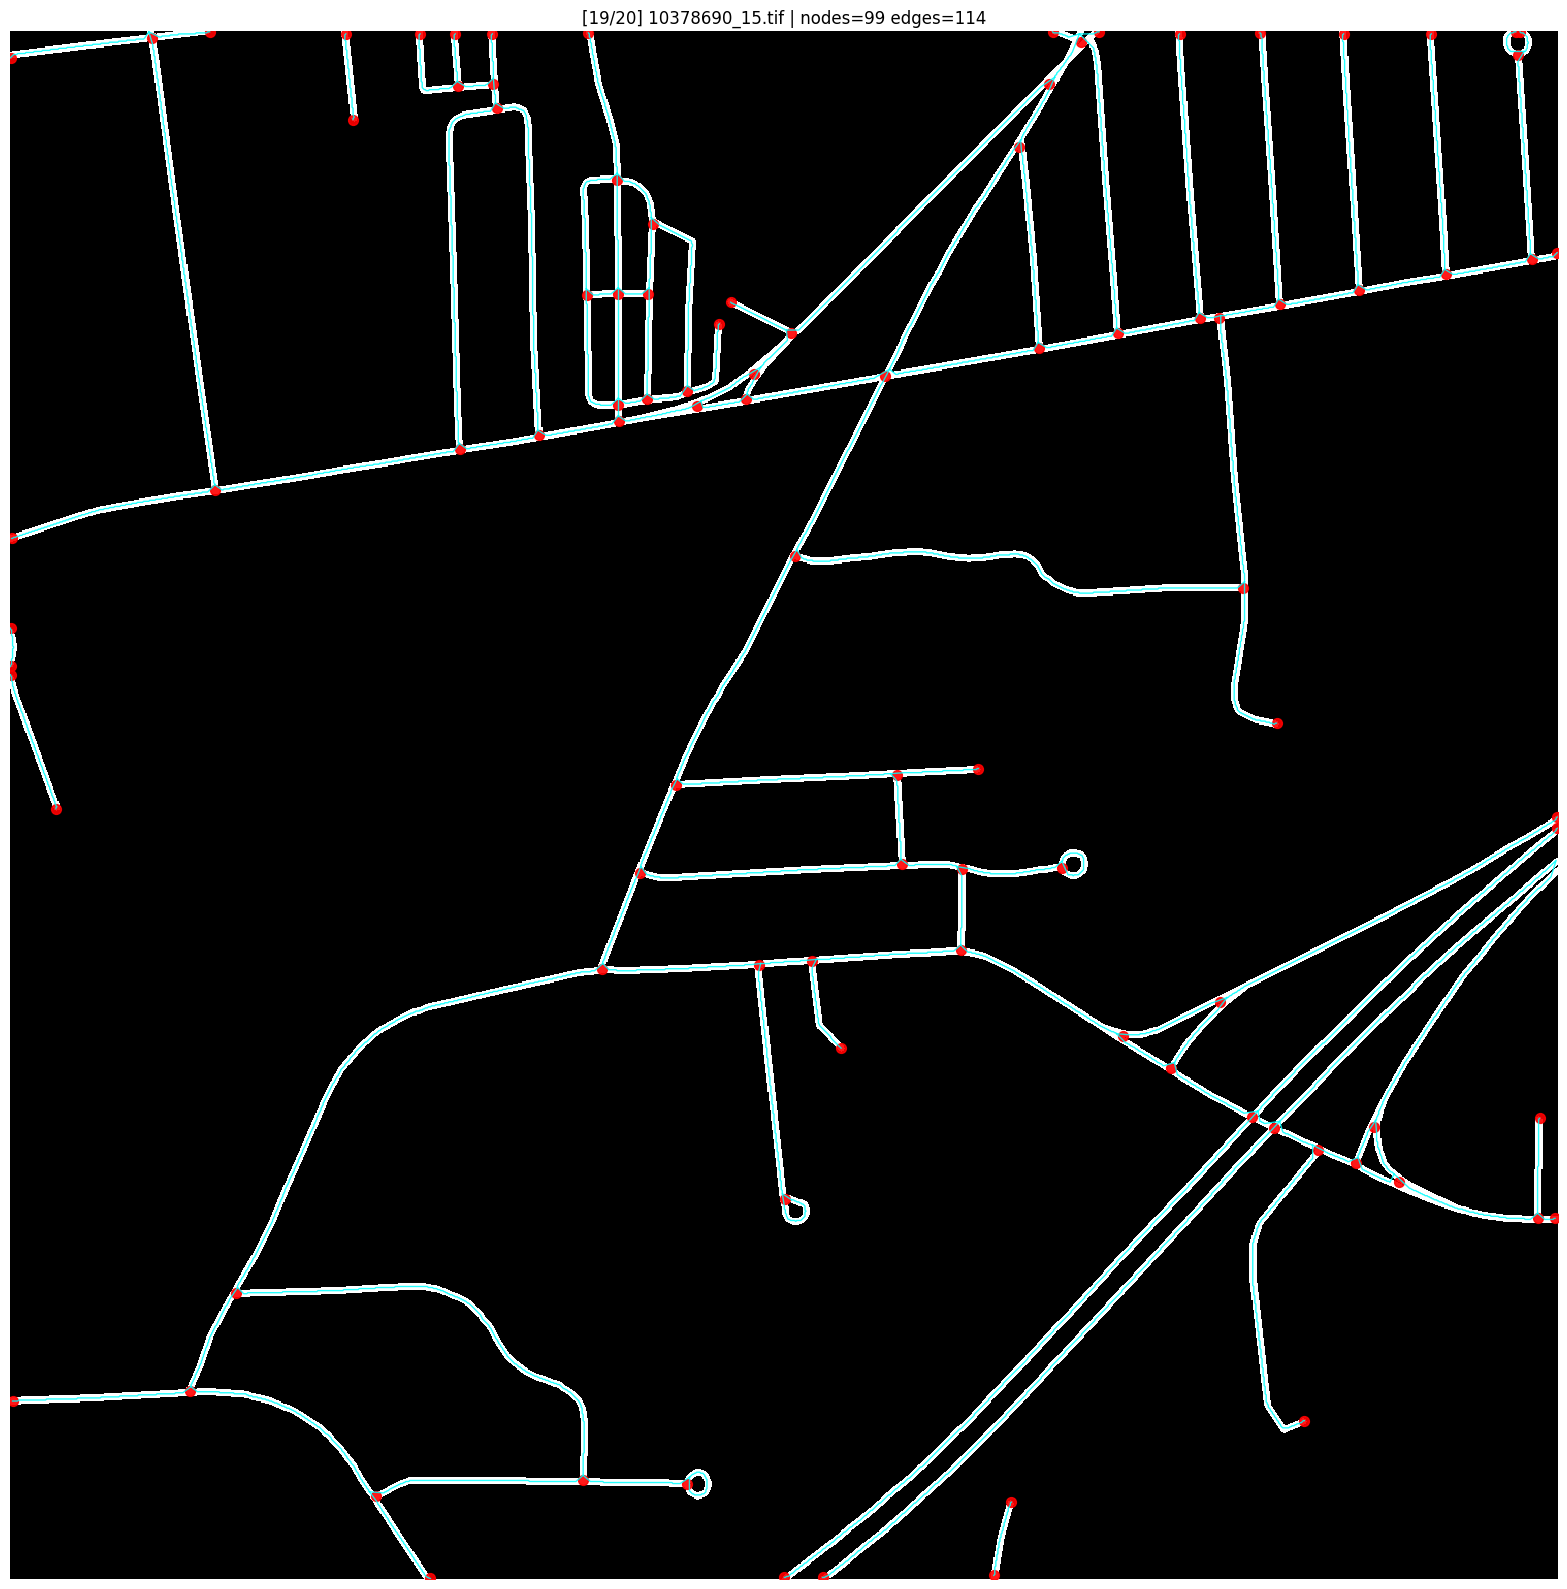

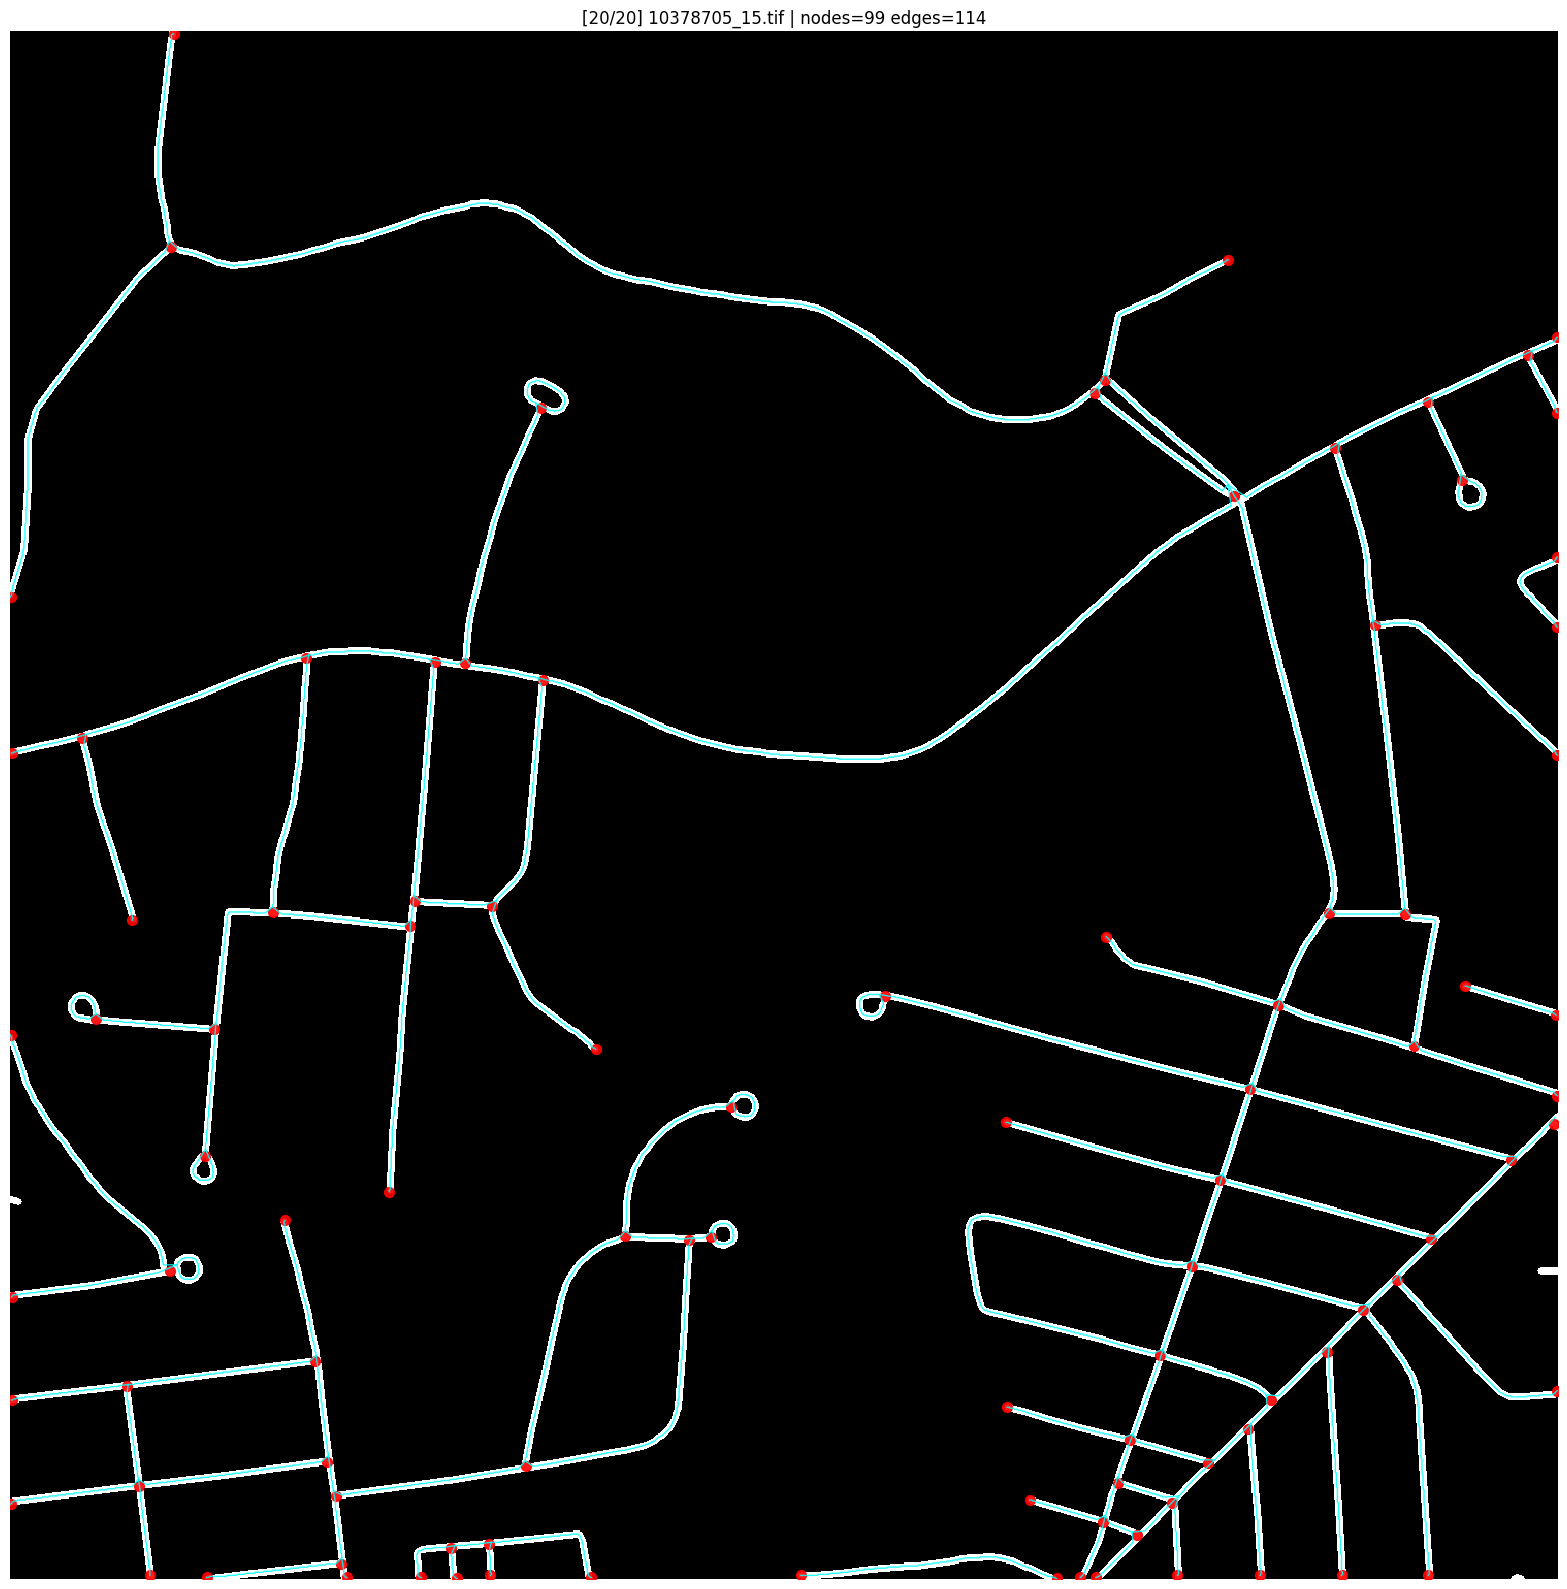

Done. Failed files: 0
Cleanup totals -> removed_objects=3, filled_holes=21
Graph totals -> avg_nodes=33.6, avg_edges=35.7


In [5]:
selected_paths = label_paths if max_files is None else label_paths[:max_files]
print(f'Processing {len(selected_paths)} label files...')

failed = []
total_removed_objects = 0
total_filled_holes = 0
total_nodes = 0
total_edges = 0

for i, path in enumerate(selected_paths, start=1):
    try:
        mask = load_binary_label(path)
        graph, debug = extract_graph(mask, config=config, return_debug=True)

        total_removed_objects += debug.cleanup_report.n_removed_objects
        total_filled_holes += debug.cleanup_report.n_filled_holes
        total_nodes += len(graph.nodes)
        total_edges += len(graph.edges)

        if debug.cleanup_report.n_removed_objects or debug.cleanup_report.n_filled_holes:
            print(
                f"{path.name}: removed={debug.cleanup_report.n_removed_objects}, "
                f"filled_holes={debug.cleanup_report.n_filled_holes}, "
                f"nodes={len(graph.nodes)}, edges={len(graph.edges)}"
            )

        title = f"[{i}/{len(selected_paths)}] {path.name} | nodes={len(graph.nodes)} edges={len(graph.edges)}"
        plot_graph_overlay(mask, graph, title)
    except Exception as exc:  # keep loop going even if one file fails
        failed.append((path.name, str(exc)))
        print(f"FAILED: {path.name} -> {exc}")

ok_count = len(selected_paths) - len(failed)
print(f"Done. Failed files: {len(failed)}")
print(f"Cleanup totals -> removed_objects={total_removed_objects}, filled_holes={total_filled_holes}")
if ok_count > 0:
    print(f"Graph totals -> avg_nodes={total_nodes / ok_count:.1f}, avg_edges={total_edges / ok_count:.1f}")
if failed:
    print('First 10 failures:')
    for name, err in failed[:10]:
        print(f"- {name}: {err}")